# <font color="steelblue">120.Análisis descriptivo: análisis relacionales</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** En este cuaderno presentamos las distintas alternativas disponibles para descubrir y describir la asociación entre dos variables, tanto si contienen información numérica (para lo que introducimos el concepto de **correlación**) como cualitativa (donde hablaremos simplemente de **asociación**). Si bien iniciamos el camino para describir la relación entre dos variables (ambas cuantitativas, ambas cualitativas o de los dos tipos), proseguimos introduciendo una tercera variable de clasificación con la que podemos discriminar varios grupos de observaciones en la muestra y concluir sobre la asociación entre las dos primeras variables, en cada uno de dichos grupos. Finalizamos el cuaderno generalizando el análisis de asociación cuando pretendemos describir todas las relaciones entre todos los pares de variables de una base de datos, incluso detallada en subgrupos de la muestra identificados por alguna variable clasificatoria.




## <font color='steelblue'> Objetivos de aprendizaje

* Entender el análisis de correlación entre dos variables numéricas, conocer, aplicar e interpretar los coeficientes de correlación.

* Entender el análisis de asociación entre dos variables categóricas, conocer, aplicar e interpretar los coeficientes de asociación (contingencia, $\phi$ y V de Cramér).

* Calcular e interpretar medidas descriptivas para variables cuantitativas en diferentes grupos o estratos de la muestra, definidos por variables categóricas.

* Realizar e interpretar el análisis de correlación y el análisis de asociación, en diferentes grupos de la muestra, identificados por alguna variable de clasificación.

* Realizar e interpretar el análisis de correlación y el análisis de asociación de un modo global en una base de datos, y también en diferentes grupos de la muestra, identificados por alguna variable de clasificación.





## <font color='steelblue'> Contenidos </font>

1. Introducción
1. Análisis de correlación entre variables cuantitativas
1. Análisis de asociación entre variables cualitativas
1. Análisis descriptivo por un factor
1. Análisis de correlación por grupos
1. Análisis de asociación por grupos
1. Análisis de correlación y asociación multivariante

## <font color='steelblue'> 1. Introducción

Una vez hemos inspeccionado el comportamiento de las variables en nuestro banco de datos a través de la descripción univariante, procedemos con la búsqueda de relaciones y asociaciones, para responder preguntas como: ¿la característica A, guarda algún tipo de relación con la característica B? ¿al variar una, cómo varía la otra?

El primer paso tras el análisis univariante es el análisis bivariante, que consiste en descubrir las relaciones entre cada par de variables cuantitativas para identificar patrones de comportamiento. Posteriormente pasremos a descriptivos más complejos.

Una concienzuda representación gráfica nos dará pistas importantes para futuros análisis estadísticos más complejos.

Cargamos las librerías y bancos de datos necesarios antes de comenzar con los diferentes análisis.

In [21]:
# Cargamos módulos de análisis numérico
import numpy as np          # importamos numpy como np
import pandas as pd         # importamos pandas como pd
import math                 # importamos módulo para cáculos matemáticos

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%config InlineBackend.figure_format = 'retina'

# Cargamos bancos de datos
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/air_pollution_seoul.csv'
pollution = pd.read_csv(url)
# Renombramos variable
pollution.rename(columns={'PM2.5': 'PM2_5'}, inplace=True)
# Convertimos formato de fecha
pollution['Date'] = pd.to_datetime(pollution['Date'])
# y podemos definir año, mes y hora
pollution['year'] = pollution['Date'].dt.year.astype('category')
pollution['month'] = pollution['Date'].dt.month.astype('category')
pollution['hour'] = pollution['Date'].dt.hour.astype('category')

## <font color='steelblue'> 2. Análisis de correlación entre variables cuantitativas

Comenzamos con el análisis descriptivo entre dos varaibles de tipo cuantitativo donde estamos interesados en conocer como se asocían los valores de una varaible respecto de otra.

La asociación o relación entre dos variables cuantitativas la estudiamos a través del **análisis de correlación**. Este análisis nos permite investigar si existe alguna **asociación ** entre dichas dos variables, esto es, si valores mayores de una van asociados con valores mayores (en cuyo caso hablamos de **asociación directa**) o valores mayores de una van asociados con valores menores de la otra (y se habla de **asociación inversa**). Además, también podemos estudiar si la asociación es lineal, esto es, si existe una proporcionalidad constante entre los valores de las dos variables, independientemente de si se trata de valores pequeños o grandes.

El objetivo de hacer un análisis de correlación y por tanto de descubrir/describir esta asociación entre dos variables, es el de plantear más tarde análisis causales y predictivos que permitan predecir el valor de una variable cuando solo disponemos del valor de otras.

El análisis de correlación se resuelve calculando unos descriptivos numéricos denominados **coeficientes de correlación**, con varias versiones que se aplican en función de cómo son los datos (básicamente en función de su simetría. Cuando podemos asumir simetría entre las variables, utilizaremos el coeficiente de correlación de Pearson (**versión paramétrica**); cuando la simetría no es evidente, utilizamos lo que llamamos **versiones no-paramétricas** del coeficiente de correlación, que no usan la distribución de los datos, como son las opciones que nos dan el coeficiente de correlación de Spearman y el de Kendall.

Todos estos coeficientes informan sobre la asociación entre las dos variables de interés. Sus valores varían siempre entre $-1$ y $1$, de forma que:

- Valores positivos para el coeficiente de correlación, $(0,1]$, informarán sobre una **relación directa** entre las variables (valores altos de una están vinculados a valores altos de la otra). Los valores negativos. , $[-1,0]$, sobre una **relación inversa** (valores altos de una están vinculados a valores bajos de la otra).

- Un coeficiente de $0$ implica ausencia de asociación, un valor de $-1$ describe una asociación inversa perfecta y un valor de $1$ una asociación directa perfecta. Valores próximos a $0$ hablan de asociación débil (positiva o negativa); valores en el intervalo $[-1,-0.5]$ de asociación inversa moderada-fuerte, y valores en el intervalo $[0.5,1]$ de asociación directa moderada-fuerte.

Procedemos a continuación presentando los coeficientes de correlación que hemos comentado anteriormente.





### <font color='steelblue'> Coeficiente de correlación de Pearson

El **coeficiente de correlación de Pearson**, o **r de Pearson** es el más común y generalizado en la práctica para calcular la correlación cuando trabajamos con dos variables de tipo cuantitativo y ambas con observaciones se reparten de forma simétrica en torno a sus medias (campana de Gauss), lo que viene a concretarse en términos de asumir 'normalidad' en sus distribuciones.

Se trata de un coeficiente que expresa el grado de **asociación lineal** entre dos variables cuantitativas. Como dijimos, existe asociación lineal entre dos variables $X$ e $Y$, básicamente cuando al representar los valores observados en una muestra a través de una nube de puntos, observamos una tendencia constante que se puede describir con una línea recta.

Para visualizar mejor este concepto de **asociación lineal** y su relación con el coeficiente de correlación de Pearson, presentamos 8 muestras con distinto grado de asociación lineal.

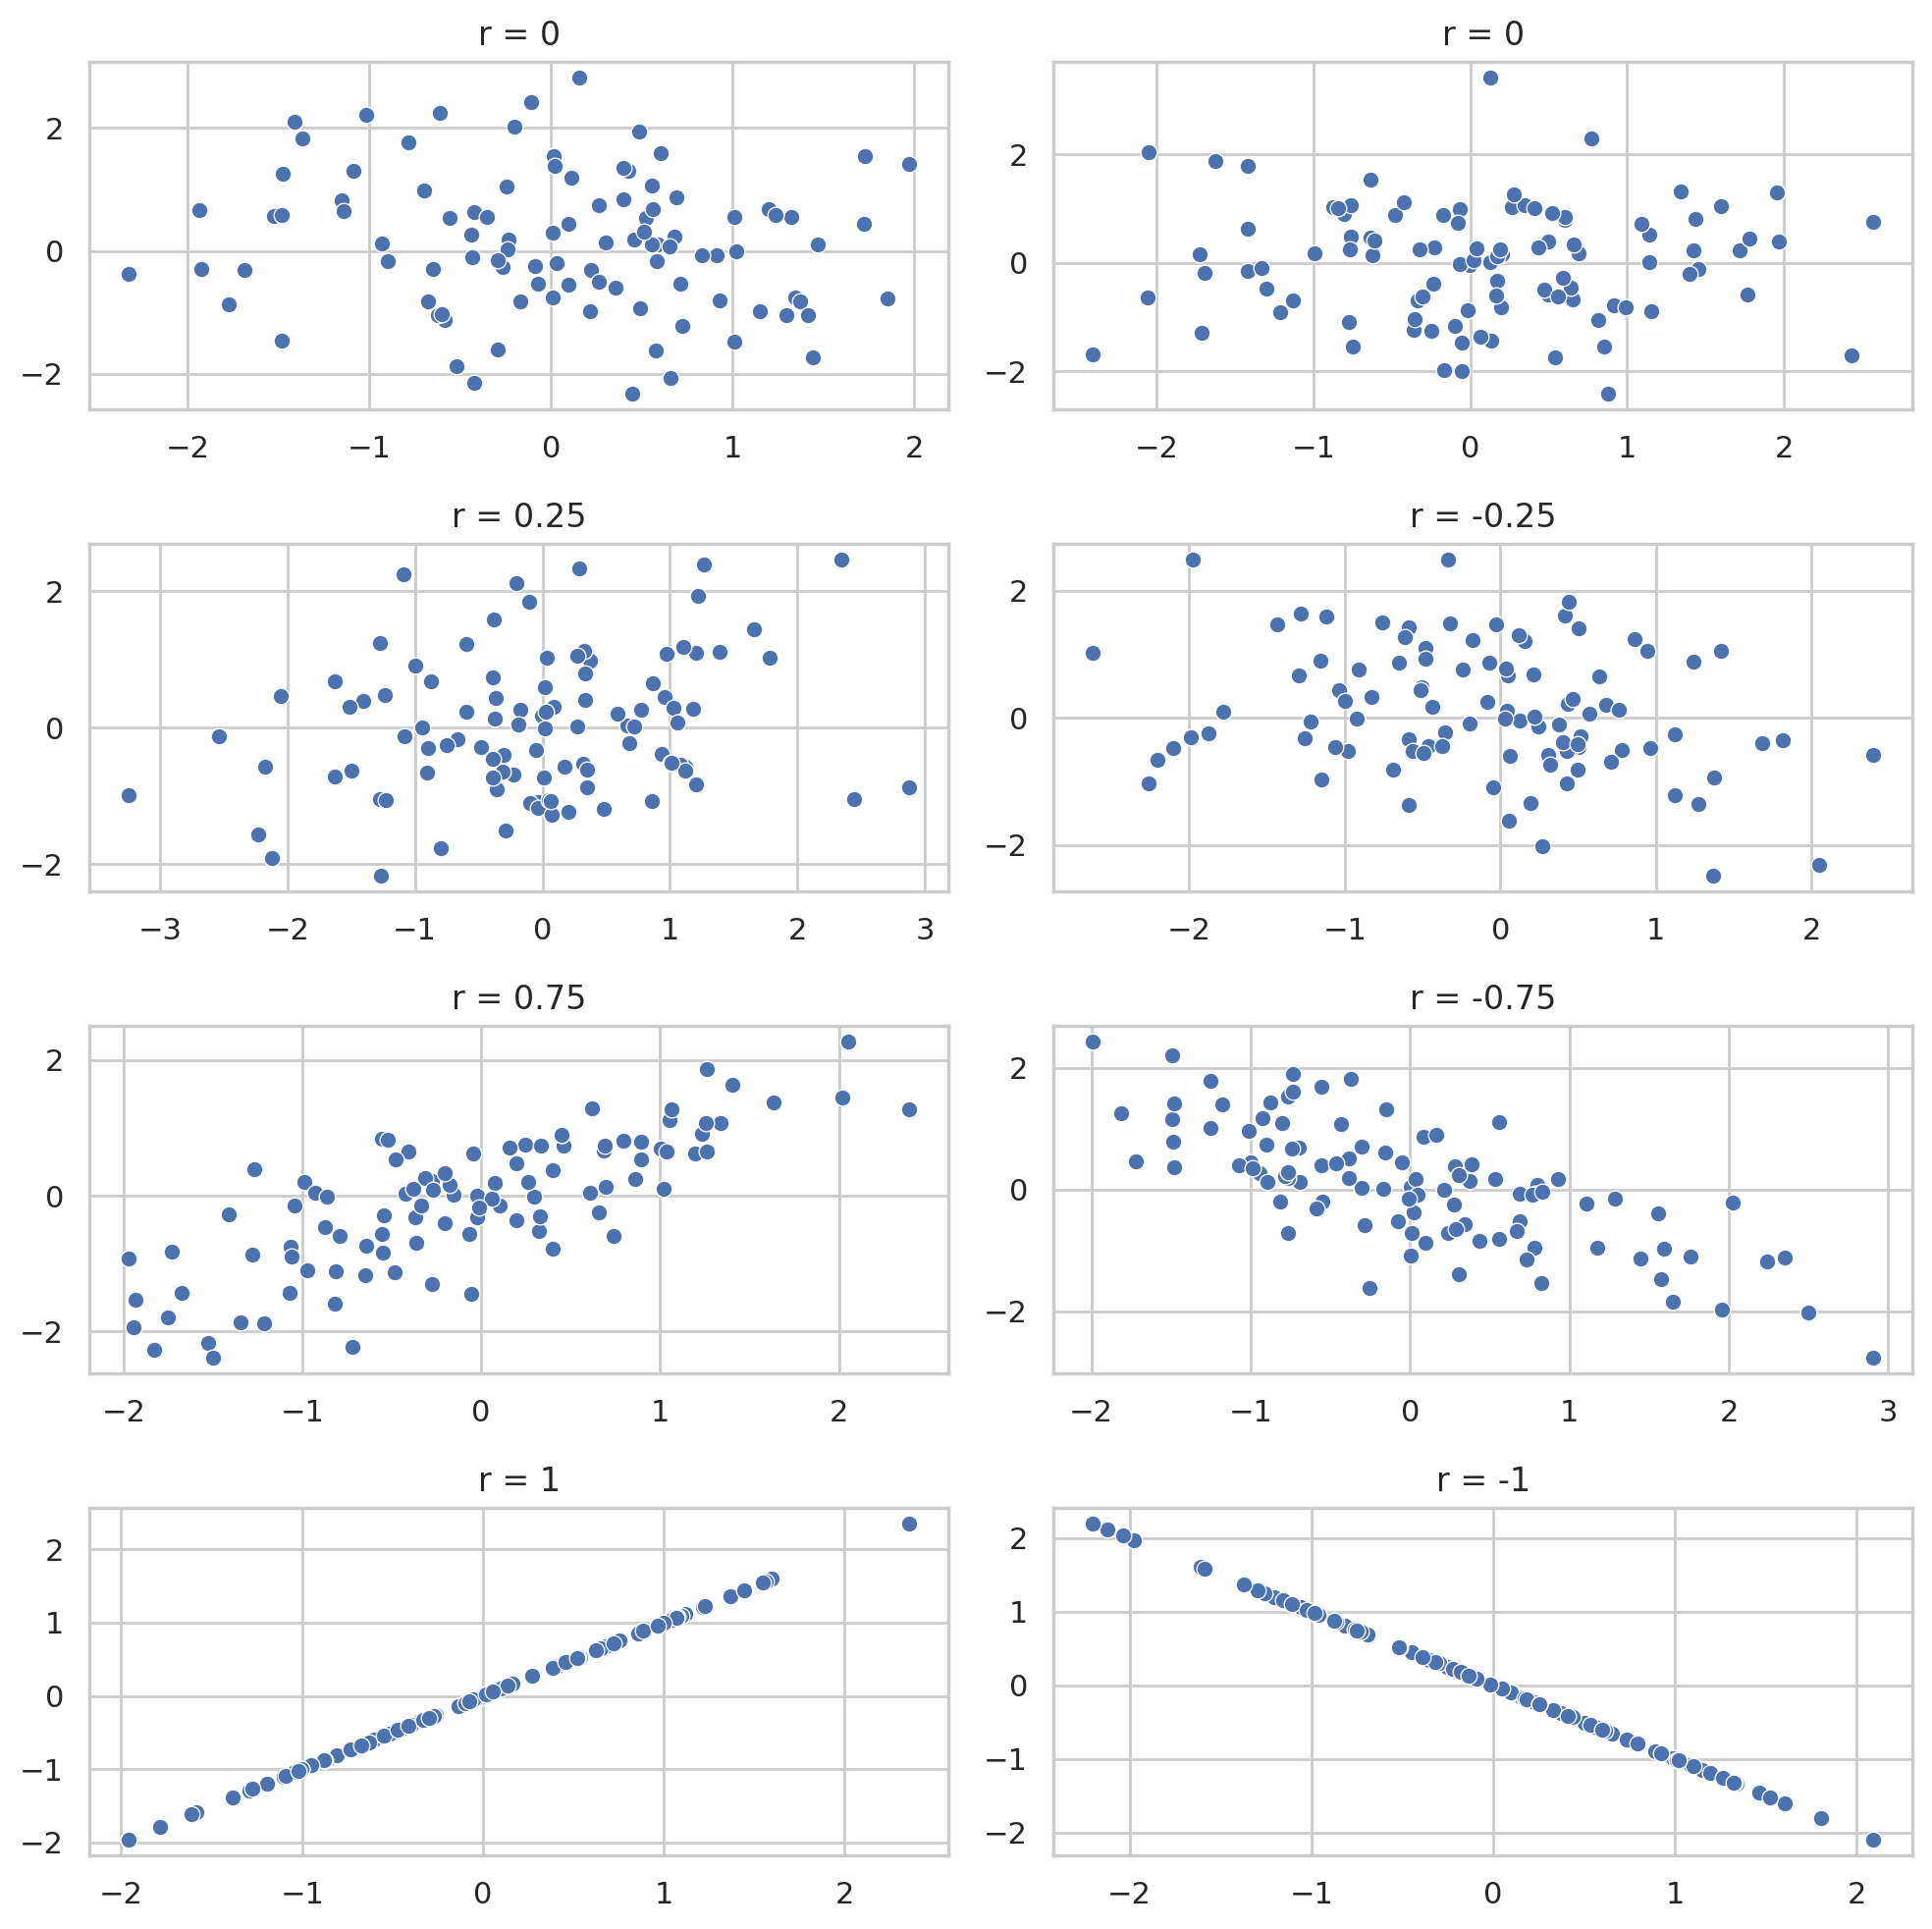

In [22]:
# @title <font color='steelblue'> Pearson gráficamente { display-mode: "form" }

sns.set_theme(style="whitegrid")

mean = [0, 0]
cov = [[1, 0], [0, 1]]
r = [0, .25, .75, 1]
rneg = [0, -.25, -.75, -1]

fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharey=False)

for s, val in enumerate(r):
    cov = [[1, val], [val, 1]]
    x, y = np.random.multivariate_normal(mean, cov, 100).T
    sns.scatterplot(x=x,y=y, ax = axes[s,0])
    plt.tight_layout()
    axes[s,0].set_title('r = ' + str(val))

for s, val in enumerate(rneg):
    cov = [[1, val], [val, 1]]
    x, y = np.random.multivariate_normal(mean, cov, 100).T
    sns.scatterplot(x=x,y=y, ax = axes[s,1])
    plt.tight_layout()
    axes[s,1].set_title('r = ' + str(val))

En los gráficos de la izquierda hemos representado situaciones de asociación lineal positiva o directa, y en la derecha negativa o inversa. El coeficiente de correlación se muestra en la cabecera de cada figura con su valor, `r=0`, `r=0.25`, ...

Partimos en ambas de correlación $0$ en la primera fila, observando sendas nubes de puntos para las que no se aprecia ninguna forma o tendencia. Hablamos en esta situación de ausencia de asociación lineal entre las variables.

Progresivamente al avanzar hacia abajo en las filas del gráfico, el coeficiente de correlación se separa del cero (en positivo o negativo) hasta llegar a una relación lineal perfecta positiva (izquierda, con `r=1`) y negativa (derecha, con `r=-1`) en la última fila.


La correlación es débil en la segunda fila, donde los coeficientes están más próximos al cero (`r=0.25` y `r=-0.25`), pero la nube de puntos de la fila anterior empieza a perfilar cierta tendencia positiva a la izquierda y negativa a la derecha.

Esa tendencia lineal se marca mejor en la tercera fila, con correlaciones altas, positiva de `r=0.75` y negativa de `r=-0.75`. Podríamos fácilmente interpolar una línea recta entre las nubes de puntos, creciente a la izquierda y decreciente a la derecha. Hablamos en este caso de una asociación lineal fuerte entre las dos variables, directa en el gráfico de la izquierda, e inversa en el de la derecha.

Si bien una inspección gráfica nos ayuda mucho al describir la relación entre dos variables, en este cuaderno nos concentramos en descriptivos numéricos. No obstante, en próximos cuadernos estudiaremos cómo crear gráficos para completar así el análisis descriptivo numérico.



El **coeficiente de correlación de Pearson** se define a partir de la covarianza entre las variables, normalizada por sus desviaciones típicas para garantizar un valor entre -1 y 1.

$$
r \thinspace de \thinspace Pearson = \frac{\sum_{i=1}^N (X_i-\bar{X})(Y_i-\bar{Y})}{\sqrt{\sum_{i=1}^N (X_i-\bar{X})^2 \cdot \sum_{i=1}^N (Y_i-\bar{Y})^2}}.
$$



En Python calculamos fácilmente la correlación entre sendas muestras de dos variables observadas $X$ e $Y$ mediante la función **`corr()`** del módulo _Pandas_, que elimina de manera automática los valores faltantes. La forma de aplicar esta función será con la sintaxis:
```
dataframe.corr()
```

Obtenemos los coeficientes de corelación correspondientes a las variables de contaminación del conjunto de datos `pollution`.

In [23]:
round(pollution[['SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2_5']].corr(),4)

,SO2,NO2,O3,CO,PM10,PM2_5
SO2,1.0000,0.0606,0.0393,0.5088,0.0688,0.0869
NO2,0.0606,1.0000,-0.2228,0.3025,0.1295,0.1850
O3,0.0393,-0.2228,1.0000,-0.1071,0.0196,0.0029
CO,0.5088,0.3025,-0.1071,1.0000,0.1633,0.2337
PM10,0.0688,0.1295,0.0196,0.1633,1.0000,0.3033
PM2_5,0.0869,0.1850,0.0029,0.2337,0.3033,1.0000


De esta tabla de correlaciones extraemos estas conclusiones:

* No hay asociaciones lineales fuertes entre ninguna de las variables monitorizadas.
* `SO2` sólo muestra cierta asociación lineal con `CO` (correlación 0.5), mientras que muestra nula asociación lineal con el resto (correlaciones inferiores a 0.1).
* `NO2` muestra correlaciones bajas con todas las varaibles pero destaca la relación inversa con `O3` y la positiva con `CO`.
* `PM10` muestra cierto grado leve (correlación=0.3) de asociación lineal directa con `PM2_5`.

Para representar la posible asociación entre dos variables cuantitativas la solución más habitual es el **gráfico de dispersión**, que también es posible representar a modo de **matriz de dispersión**, que presenta todos los gráficos de dispersión entre cada par de variables.

#### <font color='steelblue'> Gráfico de dispersión

Este gráfico representa una variable frente a otra indicando con un punto la coincidencia entre los valores de ambas variables. El conjunto de puntos representados genera una nube de puntos. Se utiliza para tener una impresión visual de la asociación entre las variables.

En Python se puede construir un gráfico de dispersión con la función de `seaborn`:

* **sns.scatterplot(datos, x, y)**, para visualizar la relación entre dos variables numéricas.

Vamos a mostrar el gráfico de dispersión entre los contaminantes `PM10` y `PM2.5`.

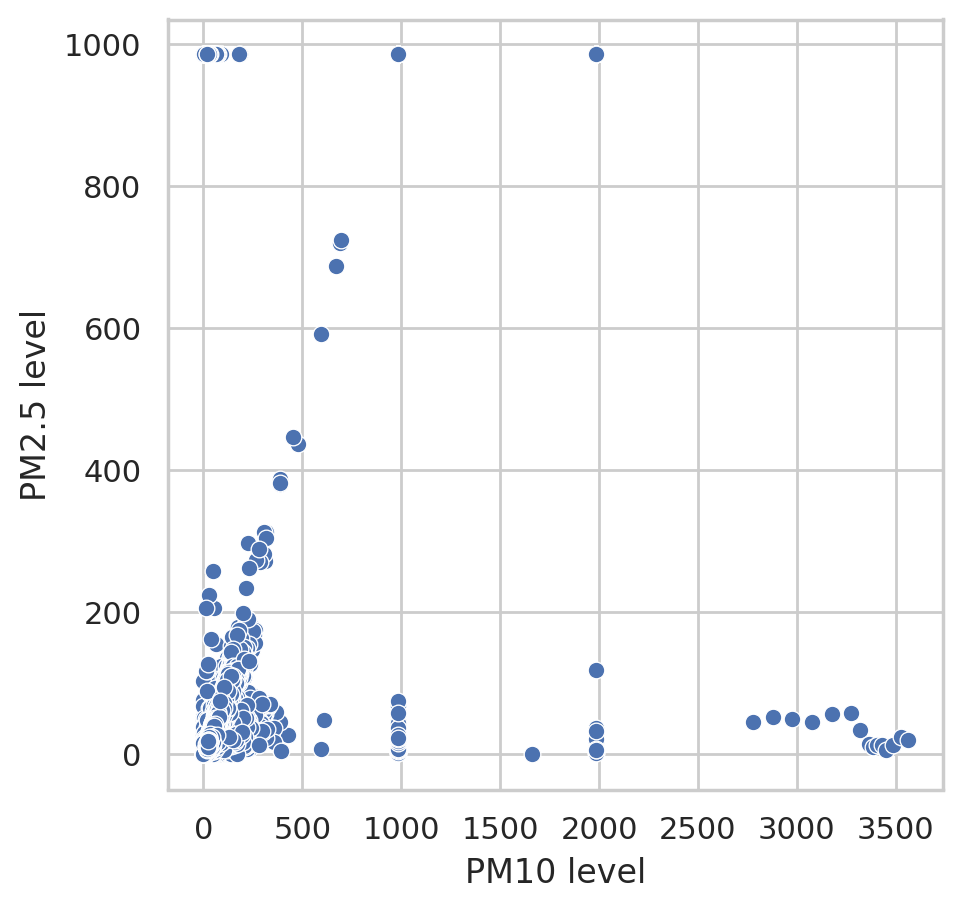

In [24]:
fig = plt.figure(figsize=(5, 5))
g = sns.scatterplot(data = pollution, x = "PM10", y = "PM2_5")
g.set(xlabel = "PM10 level", ylabel ="PM2.5 level");

Como ya apreciamos cuando calculamos las correlaciones lineales, no se observan tendencias lineales fuertes entre las variables monitorizadas. Sin embargo, parte de los datos sí que muestran una tendencia lineal entre `PM10` y `PM2_5`, lo que podría estar vinculado a alguna otra variable que habríamos de estudiar para separar los datos.

Cuando el rango de variación de las variables es muy amplio, como es el caso de `PM10` y `PM2_5`, es habitual utilizar, tanto en el análisis descriptivo como en la modelización, una transformación de las variables mediante el logaritmo. Sin embargo, esta solución tampoco ayuda a vislumbrar una asociación lineal entre dichas variables en este caso.

#### <font color='steelblue'> Gráfico matriz de dispersión

El gráfico pairplot nos permite visualizar las relaciones entre cada pareja en un conjunto de variables numéricas, además de sus distribuciones marginales.

En la diagonal puede representar histogramas o densidades (gráficos kernel) univariantes. Fuera de la diagonal se pueden visualizar los gráficos de dispersión o de densidad bivariada.

La función que se utiliza para representar esto con una única línea de código es:

* **sns.pairplot(datos, kind)**, donde kind puede tomar una de las opciones entre ["scatter","kde"].

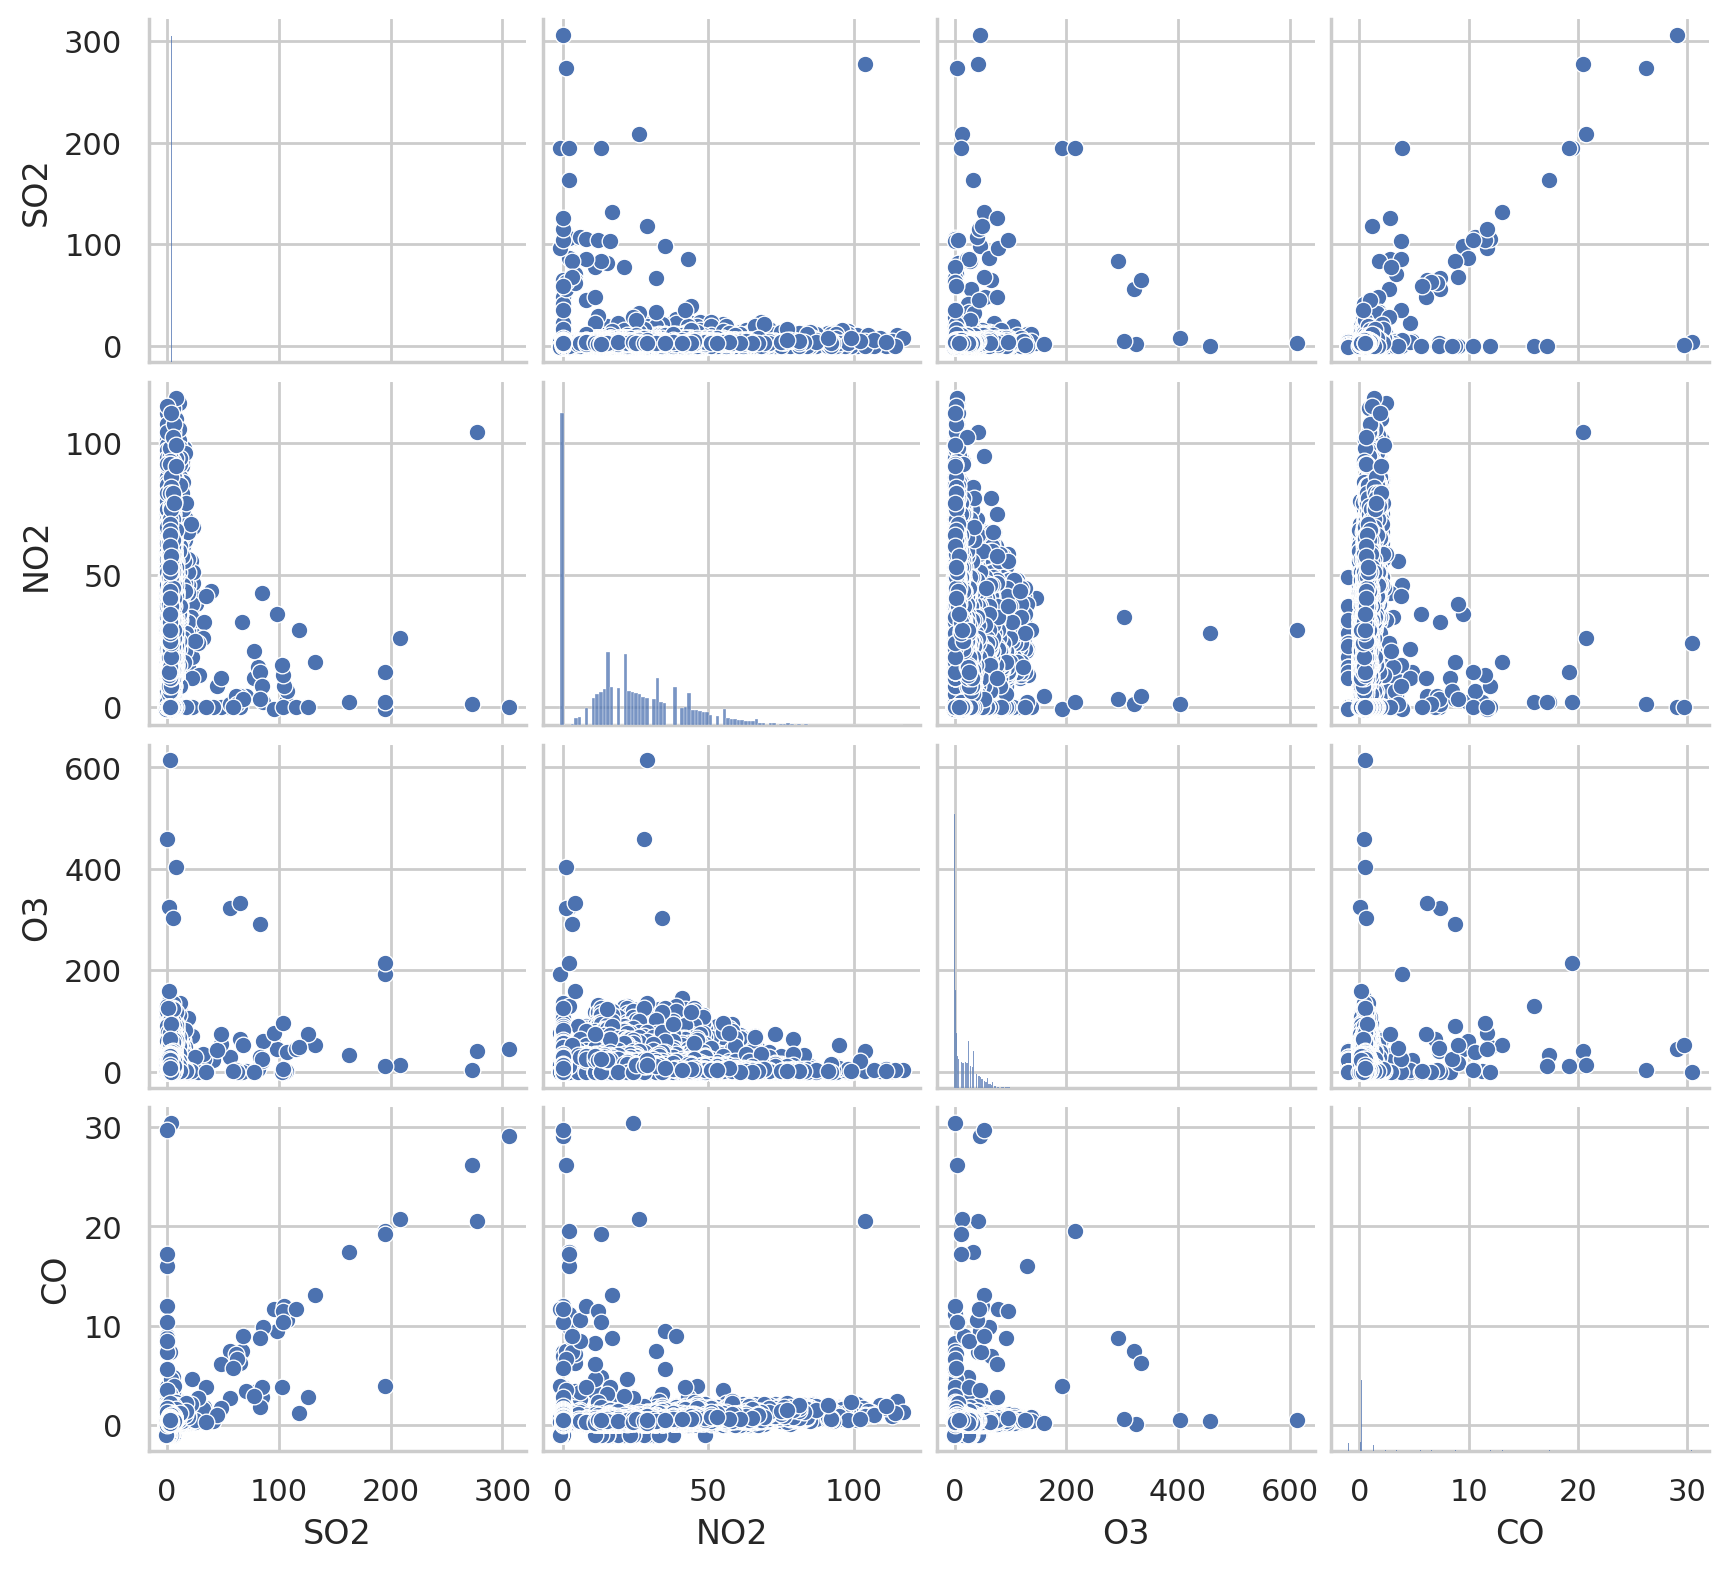

In [25]:
# Selecionamos las variables numéricas
varnum = ["SO2","NO2","O3","CO"]
sns.pairplot(pollution[varnum], height = 2, aspect =1.1);

### <font color='steelblue'> Coeficiente de correlación de Spearman

Cuando nos falla la simetría de las variables sobre las que queremos investigar asociación, esto es, la similitud de su distribución con la campana de Gauss o distribución normal, en lugar de utilizar el coeficiente de correlación de Pearson se recomienda utilizar un coeficiente que no asuma simetría. Se propone entonces utilizar el **coeficiente de correlación de Spearman**, también llamado $\rho$ **de Spearman**, que no cuantifica el grado de asociación lineal como hacía el de Pearson, pero sí si existe alguna  **tendencia monótona** entre las variables, esto es: si al crecer el valor de una, también crece (o decrece) el de la otra, aunque no sea a un ritmo constante (y por lo tanto lineal). Para calcular este coeficiente se utilizan, en lugar de los valores observados de las variables, los rangos que surgen de ordenar los valores y asignar enteros consecutivos desde el valor más bajo. Se trata pues, de una medida **no-paramétrica**, que no hace uso de las distribución de los datos, y que es más robusta para identificar tendencias cuando hay observaciones anómalas en los datos.

>Supongamos, que tenemos como observaciones de la variable $X$ los valores 12, 15, 17, 18, y como observaciones de $Y$ los valores 25, 14, 95, 30.
Los rangos que surgen entonces son:
- rangos $rx_i$ para $X$:  1, 2, 3, 4
- rangos $ry_i$ para $Y$:  2, 1, 4, 3.

Una vez tenemos los rangos, aplicamos la fórmula del coeficiente de correlación de Spearman, que viene dada en función de las diferencias entre los rangos:


$$\rho= 1- \frac{6 \sum_{i=1}^N (rx_i-ry_i)^2}{N (N^2-1)}$$

La interpretación respecto al rango de valores que identifican asociación es común a la que se planteó al inicio para todos los coeficientes de correlación. Los coeficientes de Pearson y Spearman dan valores similares cuando existe una asociación lineal entre las variables, y difieren cuando dicha asociación se aleja de la linealidad.

En Python calculamos fácilmente la correlación entre sendas muestras de dos variables observadas $X$ e $Y$ mediante la función **`corr()`** del módulo _Pandas_, que elimina de manera automática los valores faltantes. La forma de aplicar esta función será con la sintaxis:
```
dataframe.corr(method="spearman")
```

Veasmo los resultados para nuestro ejemplo:

In [26]:
round(pollution[['SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2_5']].corr(method="spearman"),4)

,SO2,NO2,O3,CO,PM10,PM2_5
SO2,1.0000,0.1376,0.0234,0.2036,0.2671,0.2459
NO2,0.1376,1.0000,-0.1848,0.4460,0.3329,0.3562
O3,0.0234,-0.1848,1.0000,-0.2032,0.0176,-0.0119
CO,0.2036,0.4460,-0.2032,1.0000,0.5371,0.5857
PM10,0.2671,0.3329,0.0176,0.5371,1.0000,0.8537
PM2_5,0.2459,0.3562,-0.0119,0.5857,0.8537,1.0000


Podemos ver que en este caso los coeficientes cambían con los obtenidos para el caso lineal. En este caso podemos ver ciertas correlaciones más relevantes como la de PM10 y PM2.5.

## <font color='steelblue'> 3. Análisis de asociación entre variables cualitativas

También cuando hemos observado dos variables cualitativas, podemos investigar si están relacionadas de algún modo. Hasta ahora, hemos estudiado cómo describir la relación entre dos variables categóricas con tablas de contingencia. Estas tablas calculaban las frecuencias observadas en todos los cruces posibles de respuestas, y así podíamos concluir sobre cuáles tenían más peso, e incluso identificar alguna tendencia. Si ahora queremos investigar específicamente si dos variables están asociadas de algún modo, esto es, no actúan de modo independiente entre sí, utilizaremos como base su tabla de contingencia, y con ella calcularemos unos estadísticos y coeficientes con los que concluir si existe asociación entre ellas y la magnitud de ésta.

En variables categóricas ciertamente no tiene sentido un análisis de correlación, puesto que no tenemos valores numéricos con los que calcular los coeficientes que propusimos. Una excepción son las variables ordinales, en las que sí podremos utilizar los coeficientes de Spearman y Kendall, si bien habrá que especificar explícitamente el orden, como ya hicimos cuando trabajamos las tablas de contingencia.

En general, cuando investigamos la relación entre dos variables cualitativas, utilizaremos las tablas de contingencia, con las que evaluaremos ciertas medidas de asociación entre las variables para concluir sobre la relación entre ellas. Estas medidas son: el estadístico $\chi^2$ (Chi-cuadrado), con el que resolveremos la asociación entre las variables, y unos coeficientes de asociación calculados a partir del estadístico $\chi^2$ con los que cuantificaremos la magnitud de la asociación, como son el **coeficiente de contingencia**, el **coeficiente** $\phi$ y la **V de Cramér**.



### <font color='steelblue'> Estadístico $\chi^2$

Un estadístico (cuando no es una persona) no es ni más ni menos que una función (fórmula) que evaluamos con las observaciones en una muestra y que de algún modo sabemos cómo se comporta en la población en la que se ha observado. Hasta ahora hemos trabajado con descriptivos como la media, la mediana, la desviación típica,..., que son *estadísticos*.

El estadístico $\chi^2$ (chi cuadrado) se calcula a partir de las frecuencias observadas en una tabla de contingencia para las $K$ combinaciones posibles de respuestas, $\{ frec.obs_i, i=1,...,K\}$, y las esperadas $\{ frec.esp_i, i=1,...,K\}$ cuando asumimos que no existe ningún tipo de relación entre las variables que estudiamos (es decir, son independientes). Su fórmula es:
$$\chi^2=\sum_{i=1}^K \frac{(frec.obs_i-frec.esp_i)^2}{frec.esp_i}$$

Para entender cómo se obtienen estas frecuencias esperadas, planteamos el problema de investigar la relación entre las variables categóricas `Dalc` y `Walc` en la base de datos 'Alcohol'. Obtenemos en primer lugar su tabla de contingencia.

In [27]:
# Cargamos los datos 'alcohol'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/student-mat.csv'
alcohol = pd.read_csv(url)
# Tabla de contingencia
tabla = pd.crosstab(alcohol["Dalc"],alcohol["Walc"],
                                 margins=True, margins_name="Total")
tabla

Walc,1,2,3,4,5,Total
Dalc,,,,,,
1,150,65,42,15,4,276
2,1,18,29,22,5,75
3,0,1,8,11,6,26
4,0,1,1,3,4,9
5,0,0,0,0,9,9
Total,151,85,80,51,28,395


Esta tabla nos proporciona pues, las frecuencias observadas $\{ frec.obs_i, i=1,...,K\}$. Para calcular las frecuencias esperadas, por ejemplo de los nivels más bajos de consumo (valores 1 en cada caso), acudimos a los totales fila y columna correspondientes, los multiplicamos y los dividimos por el total de observaciones, esto es, calculamos $frec.esp_1$ en la celda con:

$$frec.esp_1=\frac{Total(Dalc 1) \cdot Total(Walc 1)}{Total(Tabla)}=\frac{276 \cdot 151}{395}=105.51.$$

Para realizar automáticamente todos los cálculos necesarios y calcular el estadístico $\chi^2$, disponemos de la función `chi2_contingency()` en el módulo `stats` de la librería `scipy`.  Esta función se aplica a la tabla de contingencia generada y nos devuelve 4 resultados: el valor del estadístico $\chi^2$, el *p-valor* con el que valoramos la **significatividad estadística** de la asociación, un valor llamado **grados de libertad** que se calcula como el número de columnas menos 1 por el número de filas menos 1, $(ncol - 1) * (nrow - 1)$, y por último la tabla de contingencia con las frecuencias esperadas. Puesto que se trata de cuatro resultados, para acceder a ellos hemos de guardarlos (asignarlos) a cuatro variables distintas.

Por el momento nos vamos a concentrar en el valor del estadístico que utilizaremos más tarde para la obtención de índices de asociación.

Cargamos la librería y calculamos el estadístico $\chi^2$.

In [28]:
# Cálculo del estadístico Chi-cuadrado para 'sexo' y 'bmi_agrupado2'

# Importamos la librería que vamos a utilizar
import scipy.stats as ss

# Almacenamos los 4 valores en variables diferentes y aplicamos la función chi2_contingency
chi2_est, p_valor, gl, frec_esperada = ss.chi2_contingency(tabla)

# Mostramos los 4 resultados diferentes
print("Estadístico chi-cuadrado: ", chi2_est)

Estadístico chi-cuadrado:  287.0019095823893


Obtenemos para el estadístico $\chi^2$ un valor de $287.00$. Una vez obtenido el estadístico podemos calcular los diferentes índices de asocación:

- el coeficiente de contingencia
- el coeficiente $\phi$
- el coeficiente V de Cramér.

A diferencia de los coeficientes de correlación, estos coeficientes de asociación no tomarán valores negativos, puesto que no podemos hablar de crecimiento o decrecimiento en los valores de las variables (de hecho no hay valores). Además, son simétricos: la asociación entre dos variables $X$ e $Y$ es la misma que entre $Y$ y $X$.


### <font color='steelblue'> Coeficiente de contingencia

Se calcula el **coeficiente de contingencia de Pearson** como:

$$
CC = \sqrt{\frac{\chi^2}{\chi^2 + N}}
$$

donde N es el tamaño de la muestra (número total de observaciones). Este coeficiente toma valores en el intervalo $[0, 1]$, donde valores próximos a $1$ indican asociación muy fuerte entre las variables y valores próximos al $0$ asociación muy débil. Una regla general para interpretar estos valores es la siguiente:

- $CC< 0.1$: asociación débil.

- $CC\in [0.1 - 0.3]$: asociación moderada.

- $CC> 0.30$: asociación fuerte.

Calculamos ahora este coeficiente para las variables `sexo` y `bmi_agrupado2` aplicando directamente la fórmula anterior: calculamos primero el tamaño de la muestra y a continuación la raíz del cociente dado.

In [29]:
# Cálculo del coeficiente de contingencia

# cálculo del tamaño de la muesta
n = tabla.sum().sum()
# Coeficiente de contingencia
cc = np.sqrt(chi2_est/(chi2_est+n))
cc

np.float64(0.39207577727158677)

El resultado es de $0.39$, lo que muestra una asociación fuerte entre esas dos variables. Definimos una función que nos permita obteenr directamente dicho coeficiente asociación.

In [30]:
def coeficiente_contigencia(df,v1,v2):
  '''
  Función que nos porporciona el cieficnete de contigencia para dos
  variables de tipo cualitativo.

  Parámetros entrada:
  - df: dataframe de datos
  - v1: primera variable cualitativa
  - v2: segunda variable cualitativa

  Devuelve el valor del coeficiente de contigencia para una tabla
  de contingencia
  '''
  # tabla de contingencia
  tabla = pd.crosstab(df[v1],df[v2],
                       margins=True, margins_name="Total")
  # Importamos la librería que vamos a utilizar
  import scipy.stats as ss
  # Almacenamos los 4 valores en variables diferentes y aplicamos la función chi2_contingency
  chi2_est, p_valor, gl, frec_esperada = ss.chi2_contingency(tabla)
  # Cálculo del coeficiente de contingencia
  n = tabla.sum().sum()
  # Coeficiente de contingencia
  cc = np.sqrt(chi2_est/(chi2_est+n))
  print("Coeficiente de contingencia: ", round(cc,4))
  # Interpretación
  if cc < 0.1:
    print("Asociación débil")
  elif cc <= 0.3:
    print("Asociación moderada")
  else:
    print("Asociación fuerte")

Veamos su uso:

In [31]:
coeficiente_contigencia(alcohol,"Dalc","Walc")

Coeficiente de contingencia:  0.3921
Asociación fuerte


### <font color='steelblue'>Coeficiente $\phi$

El **coeficiente** $\phi$ (pronunciado 'fi') es útil, sobre todo, para tablas de contingencia con 2 filas y 2 columnas. La fórmula para calcularlo es:

$$
\phi = \sqrt{\frac{\chi^2}{N}}
$$

Al igual que en el *coeficiente de contingencia*, su valor se encuentra en el intervalo $[0, 1]$ y cuantifica la fuerza de la asociación entre las dos variables estudiadas. Se asimilan los mismos rangos de valores para su interpretación. En este caso definimos la función directamente y la utilizamos en el mismo ejemplo.

In [32]:
def coeficiente_phi(df,v1,v2):
  '''
  Función que nos porporciona el coeficiente phi para dos
  variables de tipo cualitativo.

  Parámetros entrada:
  - df: dataframe de datos
  - v1: primera variable cualitativa
  - v2: segunda variable cualitativa

  Devuelve el valor del coeficiente de contigencia para una tabla
  de contingencia
  '''
  # tabla de contingencia
  tabla = pd.crosstab(df[v1],df[v2],
                       margins=True, margins_name="Total")
  # Importamos la librería que vamos a utilizar
  import scipy.stats as ss
  # Almacenamos los 4 valores en variables diferentes y aplicamos la función chi2_contingency
  chi2_est, p_valor, gl, frec_esperada = ss.chi2_contingency(tabla)
  # Cálculo del coeficiente phi
  n = tabla.sum().sum()
  # Fórmula para la V de Cramér: raíz cuadrada de chi-cuadrao entre el tamaño de la muestra por el mínimo entre nº de filas - 1, y nº columnas - 1.
  coef_phi = np.sqrt(chi2_est/n)
  print("Coeficiente phi: ", round(coef_phi,4))
  # Interpretación
  if coef_phi < 0.1:
    print("Asociación débil")
  elif coef_phi <= 0.3:
    print("Asociación moderada")
  else:
    print("Asociación fuerte")

In [33]:
coeficiente_phi(alcohol,"Dalc","Walc")

Coeficiente phi:  0.4262
Asociación fuerte


### <font color='steelblue'> Coeficiente V de Cramér

En el caso de que la tabla de contingencia sea de mayor tamaño (con mas de 2 filas y columnas), se recomienda utilizar la **V de Cramér**, cuya fórmula es:

$$
\phi_C = \sqrt{\frac{\chi^2}{N \cdot m}}
$$

donde $N$ indica el tamaño de la muestra y $m=min\{ncol-1,nrow-1\}$ es el menor del número de columnas menos uno y del número de filas menos 1 en la tabla de contingencia.

Coindice pues su valor con el coeficiente $\phi$ en tablas de contingencia $2 \times 2$. Se interpreta la fuerza de la asociación entre dos variables categóricas según el siguiente rango de valores:

- $0<\phi_C<0.2$ asociación débil
- $\phi_C \in [0.2,0.6]$ asociación moderada
- $0.6<\phi_C<=1$ asociación fuerte.

De nuevo defiimos la función y vemos su aplicación.

In [34]:
def coeficiente_cramer(df,v1,v2):
  '''
  Función que nos porporciona el coeficiente de cramer para dos
  variables de tipo cualitativo.

  Parámetros entrada:
  - df: dataframe de datos
  - v1: primera variable cualitativa
  - v2: segunda variable cualitativa

  Devuelve el valor del coeficiente de contigencia para una tabla
  de contingencia
  '''
  # tabla de contingencia
  tabla = pd.crosstab(df[v1],df[v2],
                       margins=True, margins_name="Total")
  # Importamos la librería que vamos a utilizar
  import scipy.stats as ss
  # Almacenamos los 4 valores en variables diferentes y aplicamos la función chi2_contingency
  chi2_est, p_valor, gl, frec_esperada = ss.chi2_contingency(tabla)
  # Cálculo del coeficiente cramer
  ncol,nrow = tabla.shape
  n = tabla.sum().sum()
  # Fórmula para la V de Cramér: raíz cuadrada de chi-cuadrao entre el tamaño de la muestra por el mínimo entre nº de filas - 1, y nº columnas - 1.
  coef_cramer = np.sqrt(chi2_est/n*min(ncol-1, nrow-1))
  print("Coeficiente phi: ", round(coef_cramer,4))
  # Interpretación
  if coef_cramer < 0.2:
    print("Asociación débil")
  elif coef_cramer <= 0.6:
    print("Asociación moderada")
  else:
    print("Asociación fuerte")

In [35]:
coeficiente_cramer(alcohol,"Dalc","Walc")

Coeficiente phi:  0.953
Asociación fuerte


## <font color='steelblue'> 4. Análisis descriptivo por un factor


En muchas situaciones prácticas el interés del análisis estadístico radica en estudiar el comportamiento de una o más variables cuantitativas en función de alguna otra variable cualitativa, es decir, para los diferentes niveles o categorías de clasificación que contiene.


> En la figura a continuación tenemos una visualización de este problema. Deseamos analizar la variable identificada en marillo segmentándola (seccionándola) en función de los valores de una variable cualitativa (morado), que tiene dos niveles de clasificación: morado claro y oscuro. Quiero obtener la misma medida descriptiva (casilla rosa) en ambos grupos, para compararlos entre sí.
![Resumen de una variable](https://raw.githubusercontent.com/jmsocuellamos/DataSeg/master/img/agregar.png)

Hablamos entonces de construir **estadísticas descriptivas por estratos** o grupos de clasificación. El objetivo de este descriptivo por estratos será, claramente, la comparación de los diversos grupos que define una variable categórica o de clasificación, respecto de una variable observada de tipo cuantitativo.

Esto lo vamos a resolver con tablas descriptivas que crearemos a través de:
- **`groupby([var_clasif])[vars_describir]`** permite disgregar las columnas `vars_describir` de un dataframe en cada uno de los niveles de la variable clasificatoria `var_clasif`, para aplicarles a continuación cualquier descriptivo;
- **`pivot_table(values,index,aggfun)`** , generaliza la función anterior a más situaciones, en las que nos interesa describir más de una variable (incluida en el argumento `values`), opcionalmente respecto de alguna variable clasificatoria (en el argumento `index`), sin exigir necesariamente dos variables clasificatorias como en la función `crosstab()`.

Las funciones `crosstab()` y `pivot_table()`, ambas hacen uso de un argumento **`aggfunc`** donde se indicará una lista de los descriptivos que se desean calcular (indicados como funciones) sobre la variable de interés.

En concreto nos planteamos estudiar los viveles de contaminates para los diferentes meses en el dataframe de pollution. En eprimer luagr estudiamos el contaminante `PM10` y los describimos completamente con la función `describe()`

In [36]:
pollution.groupby(['month'])["PM10"].describe()

/tmp/ipython-input-1030414771.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
1,9276.0,59.958387,101.253161,-1.0,34.0,48.0,70.0,3561.0
2,8400.0,52.962976,50.144460,-1.0,34.0,45.0,62.0,1985.0
3,8400.0,61.445357,53.402201,-1.0,34.0,54.0,78.0,1985.0
4,9000.0,49.971889,45.152653,-1.0,29.0,44.0,64.0,1985.0
5,9075.0,54.202204,56.891329,-1.0,30.0,46.0,66.0,1985.0
6,9000.0,37.343667,59.509849,-1.0,22.0,33.0,46.0,1985.0
7,9225.0,29.449864,60.763490,-1.0,14.0,25.0,37.0,1985.0
8,9256.0,25.926858,62.564518,-1.0,14.0,21.0,30.0,1985.0
9,8700.0,25.765287,53.104582,-1.0,12.0,20.0,31.0,1985.0


Siguen a apreciendo valores -1 que debemos convertir em NaN

In [37]:
numerical_cols = ['SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2_5']
pollution[numerical_cols] = pollution[numerical_cols].replace(-1, np.nan)

Elaboramos la tabla de nuevo

In [38]:
pollution.groupby(['month'])["PM10"].describe()

/tmp/ipython-input-1030414771.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
1,9268.0,60.011006,101.281008,0.0,34.0,48.0,70.0,3561.0
2,8369.0,53.162863,50.129375,0.0,35.0,45.0,62.0,1985.0
3,8367.0,61.691646,53.362927,0.0,34.0,54.0,78.0,1985.0
4,8994.0,50.005893,45.148507,0.0,29.0,44.0,64.0,1985.0
5,9061.0,54.287496,56.893836,0.0,30.0,46.0,67.0,1985.0
6,8994.0,37.369246,59.521453,0.0,22.0,33.0,46.0,1985.0
7,9185.0,29.582471,60.862360,0.0,14.0,26.0,37.0,1985.0
8,9233.0,25.993935,62.627948,0.0,14.0,21.0,30.0,1985.0
9,8440.0,26.589810,53.705035,0.0,13.0,21.0,32.0,1985.0


En este caso podemos ver como el valor del contaminante va reduciendo hacia los mese más calurosos, y comienza a aumentar de nuevo cuando el efecto de frio se hace notar.

Podemos obtener una solución similar con `pivot_table`. En este caso analizamos todas las variables numéricas con respecto al mes, pero nos centramos únicamente en la media y desviación típica.

In [39]:
# Tabla descriptiva
tabla = pd.pivot_table(pollution,
               values = ['SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2_5'],
               index = ['month'],
               aggfunc = {'mean', 'std'})
# redondeamos para no mostrar muchos decimales
round(tabla, 2)

/tmp/ipython-input-3001246439.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


CO          NO2            O3          PM10          PM2_5         \
       mean   std   mean    std   mean    std   mean     std   mean    std   
month                                                                        
1      0.69  0.47  28.50  21.73   9.84  10.07  60.01  101.28  34.67  35.04   
2      0.64  0.33  26.96  21.57  13.43  13.10  53.16   50.13  32.29  33.89   
3      0.59  0.57  27.24  21.89  19.84  19.13  61.69   53.36  41.02  36.10   
4      0.48  0.35  23.70  19.09  23.90  21.20  50.01   45.15  24.91  32.72   
5      0.46  0.35  21.88  16.90  28.98  25.67  54.29   56.89  25.74  24.25   
6      0.41  0.15  17.96  13.64  29.12  23.95  37.37   59.52  22.93  34.45   
7      0.39  0.16  15.25  11.72  21.47  22.92  29.58   60.86  20.06  35.99   
8      0.39  0.24  14.56  11.31  21.46  21.87  25.99   62.63  15.40  38.91   
9      0.42  0.31  17.41  14.18  19.43  18.38  26.59   53.71  15.00  41.47   
10     0.47  0.39  20.67  17.10  14.68  14.92  28.64   37.84  14.75  22.59   
11     0.61  0.27  27.41  20.26   9.40  10.63  46.78   63.52  23.68  24.18   
12     0.65  0.36  27.19  20.50   8.37   8.95  48.62  106.50  28.22  29.41   

        SO2        
       mean   std  
month              
1      4.21  2.69  
2      4.18  2.60  
3      4.02  5.19  
4      3.83  3.96  
5      3.96  3.72  
6      3.66  1.60  
7      3.57  1.53  
8      3.60  2.93  
9      3.47  2.78  
10     3.49  3.30  
11     3.90  2.06  
12     3.93  2.13

¿qué podemos decir del coportamiento medio de cada contaminante a lo largo de los meses?

Dado que el análisis de estas tablas puede resultar muy complejo podemos introducir soluciones gráficas que nos permitan concluir de forma más precisa sobre el análisis descriptivo. En concreto nos centramos en el uso de diagramas de caja para comparar el comportamiento de la varaible numérica para los diferentes niveles de la variable cualitativa.

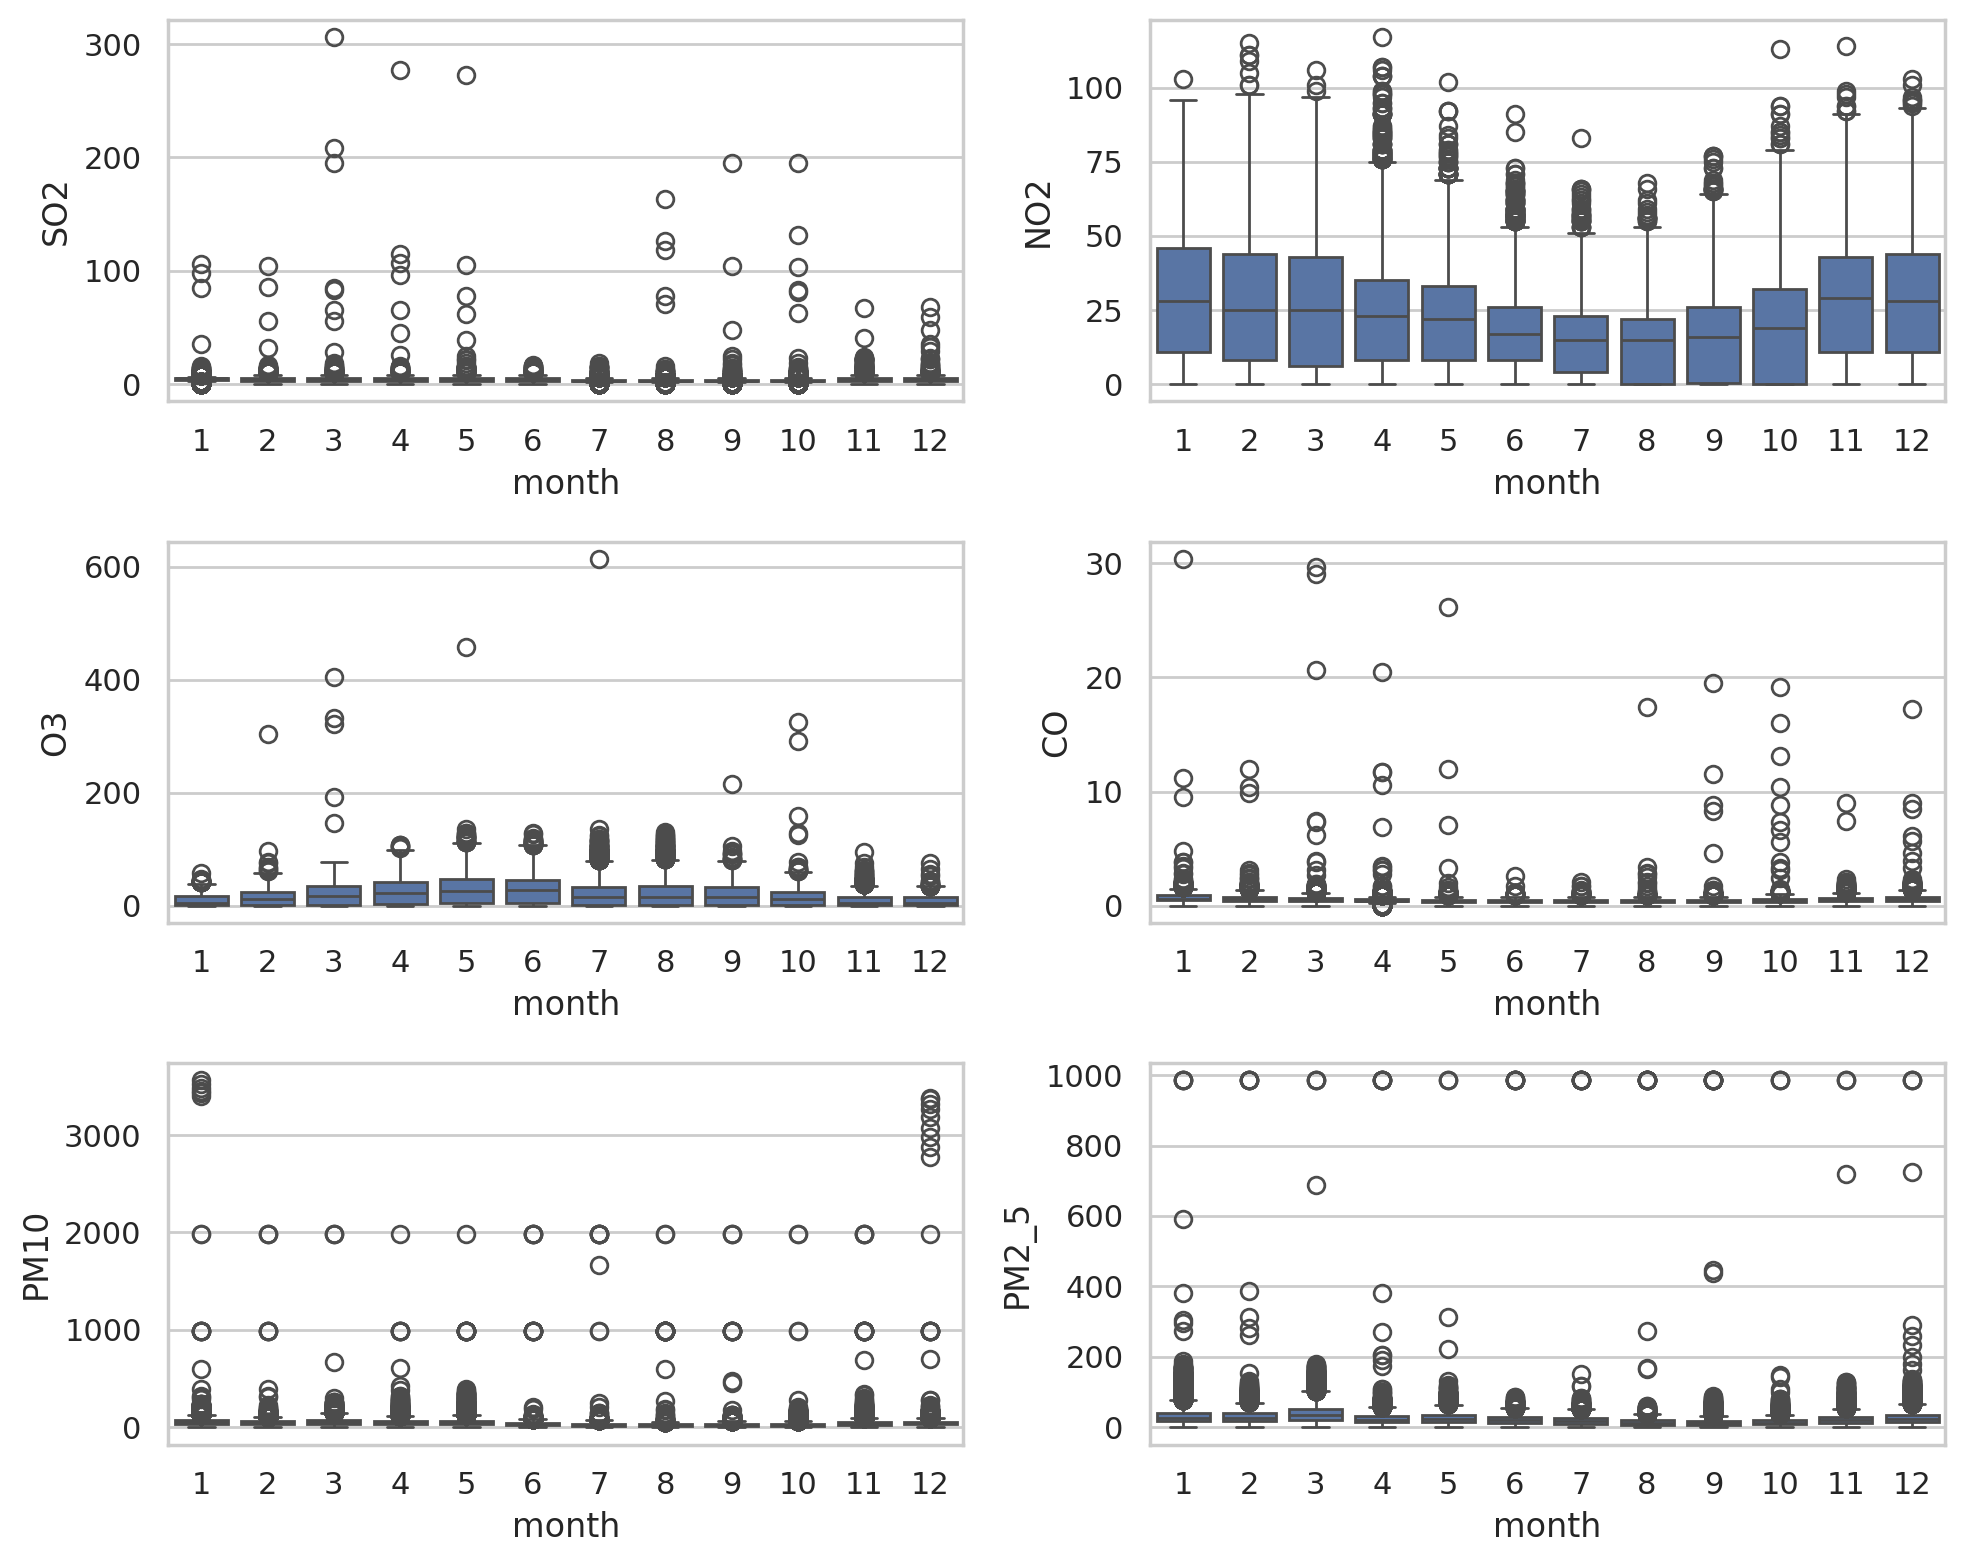

In [40]:
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(10, 8))
varnum = ['SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2_5']
# primer subgráfico
for i in range(len(varnum)):
  plt.subplot(3,2,i+1)
  g = sns.boxplot(data = pollution, x = "month", y = varnum[i])
# Ajustamos los gráficos
plt.tight_layout()

Como en otras ocasiones con este banco de datos, la gran avariabilidad en las observaciones provica que sea díficil visualizar el comportamiento de los datos. Sim embargo, se aprecia claramente el comportamiento del `NO2` donde su vaores más pequeños se obtienen en los meses más calurosos.

## <font color='steelblue'> 5. Análisis de correlación por grupos

En ocasiones nos interesa subdividir una muestra en diferentes grupos, identificados por alguna variable de clasificación, y en cada uno de estos subgrupos investigar la correlación entre dos variables numéricas.

Esto sin duda, nos da información más detallada sobre si existe alguna asociación entre las variables solo en determinados subgrupos de población.

En nuestro caso vamos a utilizar el dataframe iris y vamos a estudiar como se relacionan las variables numéricas con respecto al tipo de especie de flor.



In [41]:
# Cargamos los datos
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/IRIS.csv'
iris = pd.read_csv(url)
# Correlaciones diferenciando por tipo de especie
tbcor = iris.groupby("species").agg('corr')
tbcor

sepal_length  sepal_width  petal_length  \
species                                                                 
Iris-setosa     sepal_length      1.000000     0.746780      0.263874   
                sepal_width       0.746780     1.000000      0.176695   
                petal_length      0.263874     0.176695      1.000000   
                petal_width       0.279092     0.279973      0.306308   
Iris-versicolor sepal_length      1.000000     0.525911      0.754049   
                sepal_width       0.525911     1.000000      0.560522   
                petal_length      0.754049     0.560522      1.000000   
                petal_width       0.546461     0.663999      0.786668   
Iris-virginica  sepal_length      1.000000     0.457228      0.864225   
                sepal_width       0.457228     1.000000      0.401045   
                petal_length      0.864225     0.401045      1.000000   
                petal_width       0.281108     0.537728      0.322108   

                              petal_width  
species                                    
Iris-setosa     sepal_length     0.279092  
                sepal_width      0.279973  
                petal_length     0.306308  
                petal_width      1.000000  
Iris-versicolor sepal_length     0.546461  
                sepal_width      0.663999  
                petal_length     0.786668  
                petal_width      1.000000  
Iris-virginica  sepal_length     0.281108  
                sepal_width      0.537728  
                petal_length     0.322108  
                petal_width      1.000000

Podemos ver por ejemplo la correlación más alta dentro de la especie `Iris-setosa` se produce entre las dos medidas de sépalo. Dicha correlación es bastante intensa ya que le corresponde un valor de 0.75. Además, todas las correalciones observadas son positivas indicandoq ue cuando aumenta una variable lo hace también la otra independientemente de la especie considerada.

A continuación exploramos la solución gráfica utilizando la función pairplot pero identificando por el tipo de especie.

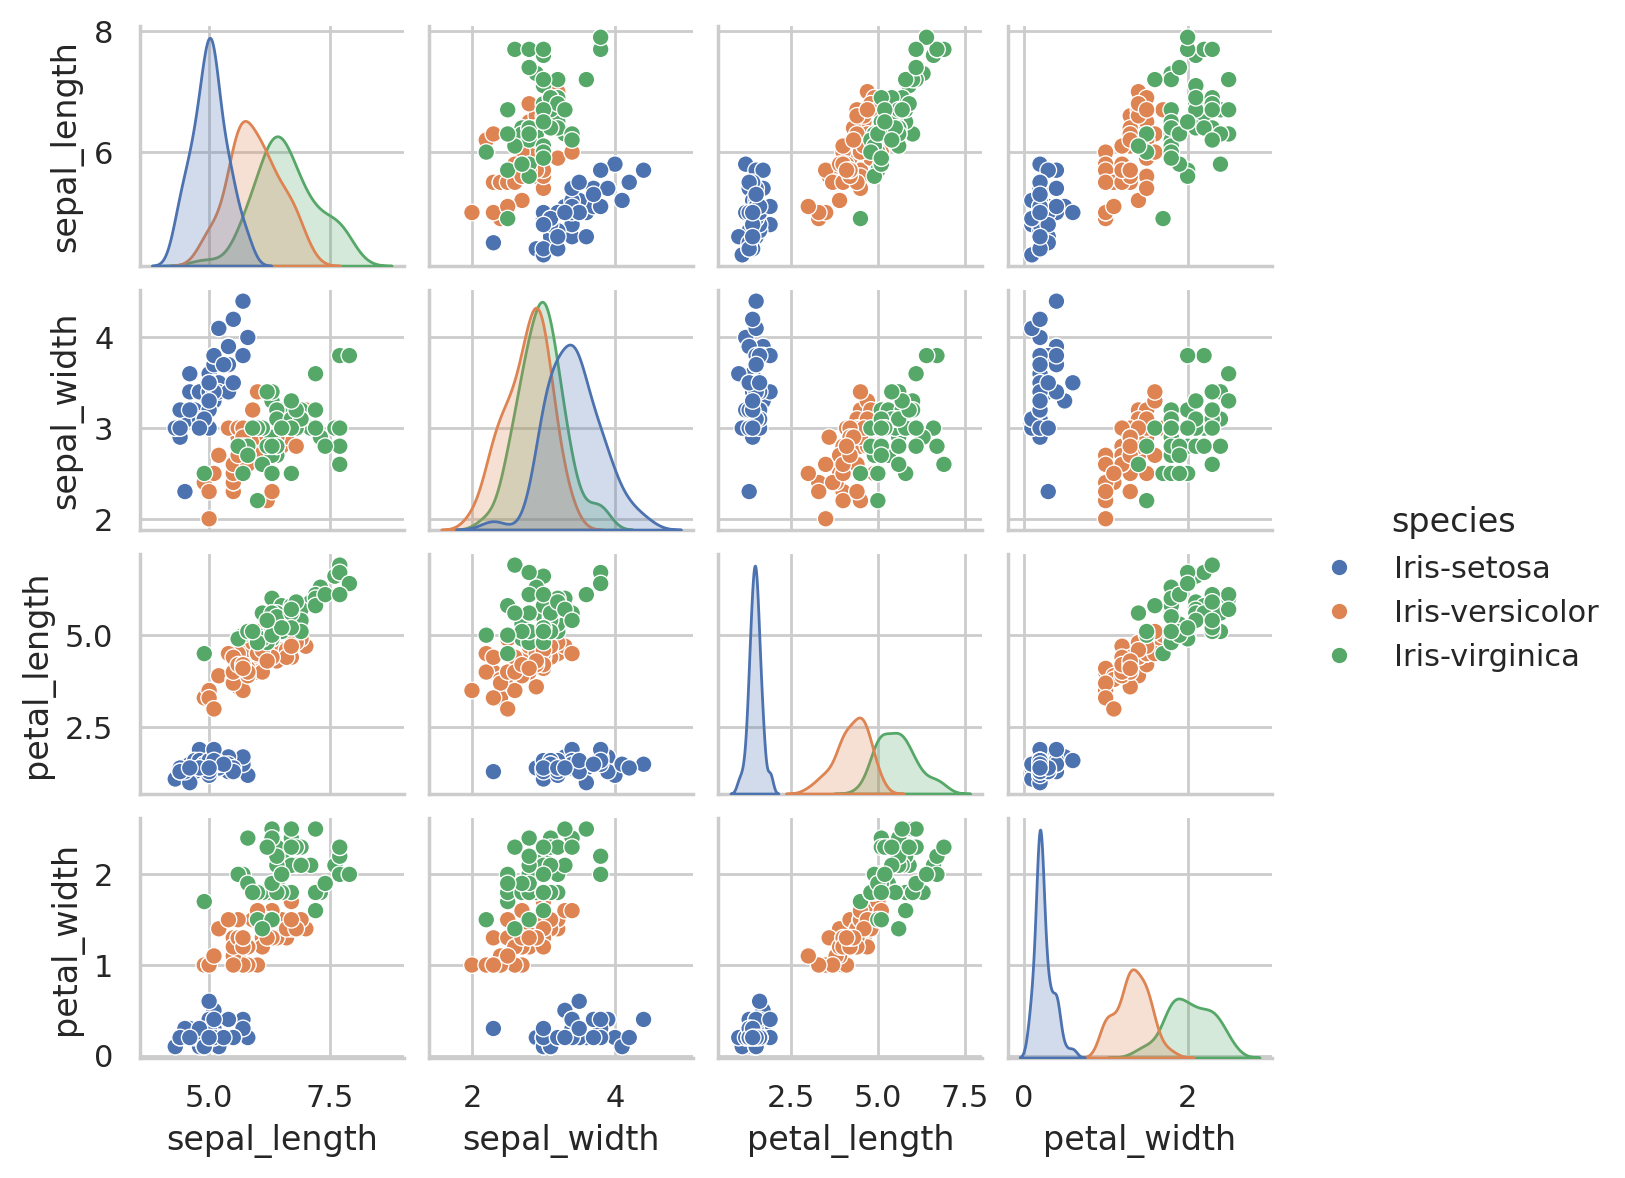

In [42]:
# Gráfico
sns.pairplot(iris, hue = "species", height = 1.5, aspect =1.1)

Al representar los tres tipos de especies se pueden ver claramente las distintas tendencias en la nube de puntos para explicar la asociación entre variables, dependiendo siempre de la especie en cuestión. Las iris setosa tienen un comportamiento muy diferente a las otras dos especies, versicolor y virginica. Para estas dos especies se distinguen claramente las correspondientes nubes de puntos, si bien en ocasiones se entremezclan los puntos.

Las curvas de densidad dan una información ciertamente dispar para las tres especies, pero muestran un comportamiento bastante simétrico en todos los casos con lo que no es necesario proceder con otro índice de correlación para interpretar la asociación entre las varaibles numéricas.

La moraleja a aplicar es que siempre hay que dibujar los datos cuando investigamos relaciones estadísticas, y profundizar utilizando la información en las variables disponibles.

## <font color='steelblue'> 6. Análisis de asociación por grupos

En ocasiones nos interesa subdividir una muestra en diferentes grupos, identificados por alguna variable de clasificación, y en cada uno de estos subgrupos investigar la asociación entre dos variables categóricas.

Esto sin duda, nos da información más detallada sobre si existe alguna asociación entre las variables solo en determinados subgrupos de población.

En nuestro caso estudiamos la posible asociación entre `Dalc` y `Walc` según el nivel de estudios del padre `Fedu` en el dataframe alcohol.



In [43]:
# Recodificamos etiquetas
alcohol.Fedu.replace({0: "none", 1: "primary education", 2: "5th to 9th grade", 3: "secondary education", 4: "higher education"}, inplace=True)
# identificamos los grupos de clasificación
grupos = alcohol.groupby("Fedu").groups
# hacemos una lista con los nombres de los subgrupos
g=list(grupos.keys())

# creamos  listas vacías para almacenar los coeficientes
cc=[]

# recorremos estos grupos y calculamos las correlaciones en cada uno
for i in g:
  tabla = pd.crosstab(alcohol.Dalc[grupos[i]],
                                   alcohol.Walc[grupos[i]])
  # aplicamos la función chi2_contingency
  chi2_est, p_valor, gl, frec_esperada = ss.chi2_contingency(tabla)

  # calculamos el tamaño de la muesta
  n = tabla.sum().sum()

  # Coeficiente de contingencia
  cc.append(np.sqrt(chi2_est/(chi2_est+n)))

# mostramos los resultados
print("Coeficientes de asociación")
pd.DataFrame({'cc':cc},index=g)

Coeficientes de asociación


/tmp/ipython-input-4281386762.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




,cc
5th to 9th grade,0.725397
higher education,0.673638
none,0.000000
primary education,0.654440
secondary education,0.659798


Podemos ver como el mayor valor de asoación entre las variables de interés se produce dentro del grupo `5th to 9th grade`, pero en todos ellos se aprecía un asociación fuerte entre ambas variables.

## <font color='steelblue'> 7. Describir relaciones entre múltiples variables cuantitativas y cualitativas


Tratamos de generalizar los procedimientos numéricos y gráficos anteriores para estudiar relaciones a la casuística en que tenemos múltiples variables cualitativas y cuantitativas.

Utilizaremos las funciones:

* **`pd.pivot_table`** para los análisis descriptivos numéricos
* **`sns.relplot`** para gráficos de dispersión ante varias variables cualitativas
* **`sns.FacetGrid`** para los análisis gráficos
* **`sns.catplot`** que es una versión modificada de `FacetGrid` para gráficos multidimensionales con variable categórica en el eje X.


Nos centrasmos de nuevo en el dataframe `alcohol`. Realizamos un estudio de las variables numéricas `absences` y `age` en función de las variables categóricas `Dalc`, `Walc` y `health`.

Algunas de las preguntas que podríamos plantear son:

1. ¿Están relacionadas las ausencias a la escuela con el consumo de alcohol en días laborables y en fines de semana?
2. ¿Cuál es la edad media de los estudiantes que consumen más alcohol en días laborables? ¿Y la de los que consumen más en fines de semana?
3. El nivel de salud, ¿varía con la edad de los estudiantes en función del consumo de alcohol en días laborables y fines de semana?
4.  ¿Están asociados de igual forma la edad y las ausencias a la escuela, en cualquiera de los grupos de consumo de alcohol definido el consumo en día laborable y en fines de semana?

Veamos cómo realizar cualquier descriptivo y de asociación en este tipo de situaciones.

En primer lugar obtenemos la tabla de descriptivos

In [44]:
# Calculamos la tabla de descriptivos
tabla = pd.pivot_table(alcohol,
               values = ['absences','age'],
               index = ['Dalc', 'Walc', 'health'],
               aggfunc = {'count', 'mean', 'std'})
# redondeamos para no presentar muchos decimales
round(tabla,2)

absences                 age             
                    count   mean    std count   mean   std
Dalc Walc health                                          
1    1    1            20   2.85   3.80    20  16.20  1.32
          2            15   7.40   7.89    15  16.40  1.24
          3            41   4.39   7.38    41  16.90  1.34
          4            28   5.82   7.78    28  16.79  1.26
          5            46   4.83  11.54    46  15.98  1.24
...                   ...    ...    ...   ...    ...   ...
4    5    5             1  12.00    NaN     1  17.00   NaN
5    5    1             1  16.00    NaN     1  22.00   NaN
          3             1   4.00    NaN     1  15.00   NaN
          4             4   6.50   5.97     4  17.00  0.82
          5             3  10.67   5.03     3  16.67  1.15

[66 rows x 6 columns]

Como hay muchas combinaciones al mezclar las tres variables categóricas, la tabla resulta muy grande y es complicado visualizar relaciones. Los gráficos, en estos casos, nos pueden ayudar a mejorar la visualización de la información.

En primer lugar proponemos un diagrama de dispersión entre las variables cuantitativas para cada una de las combinaciones de niveles de las tres variables cualitativas.

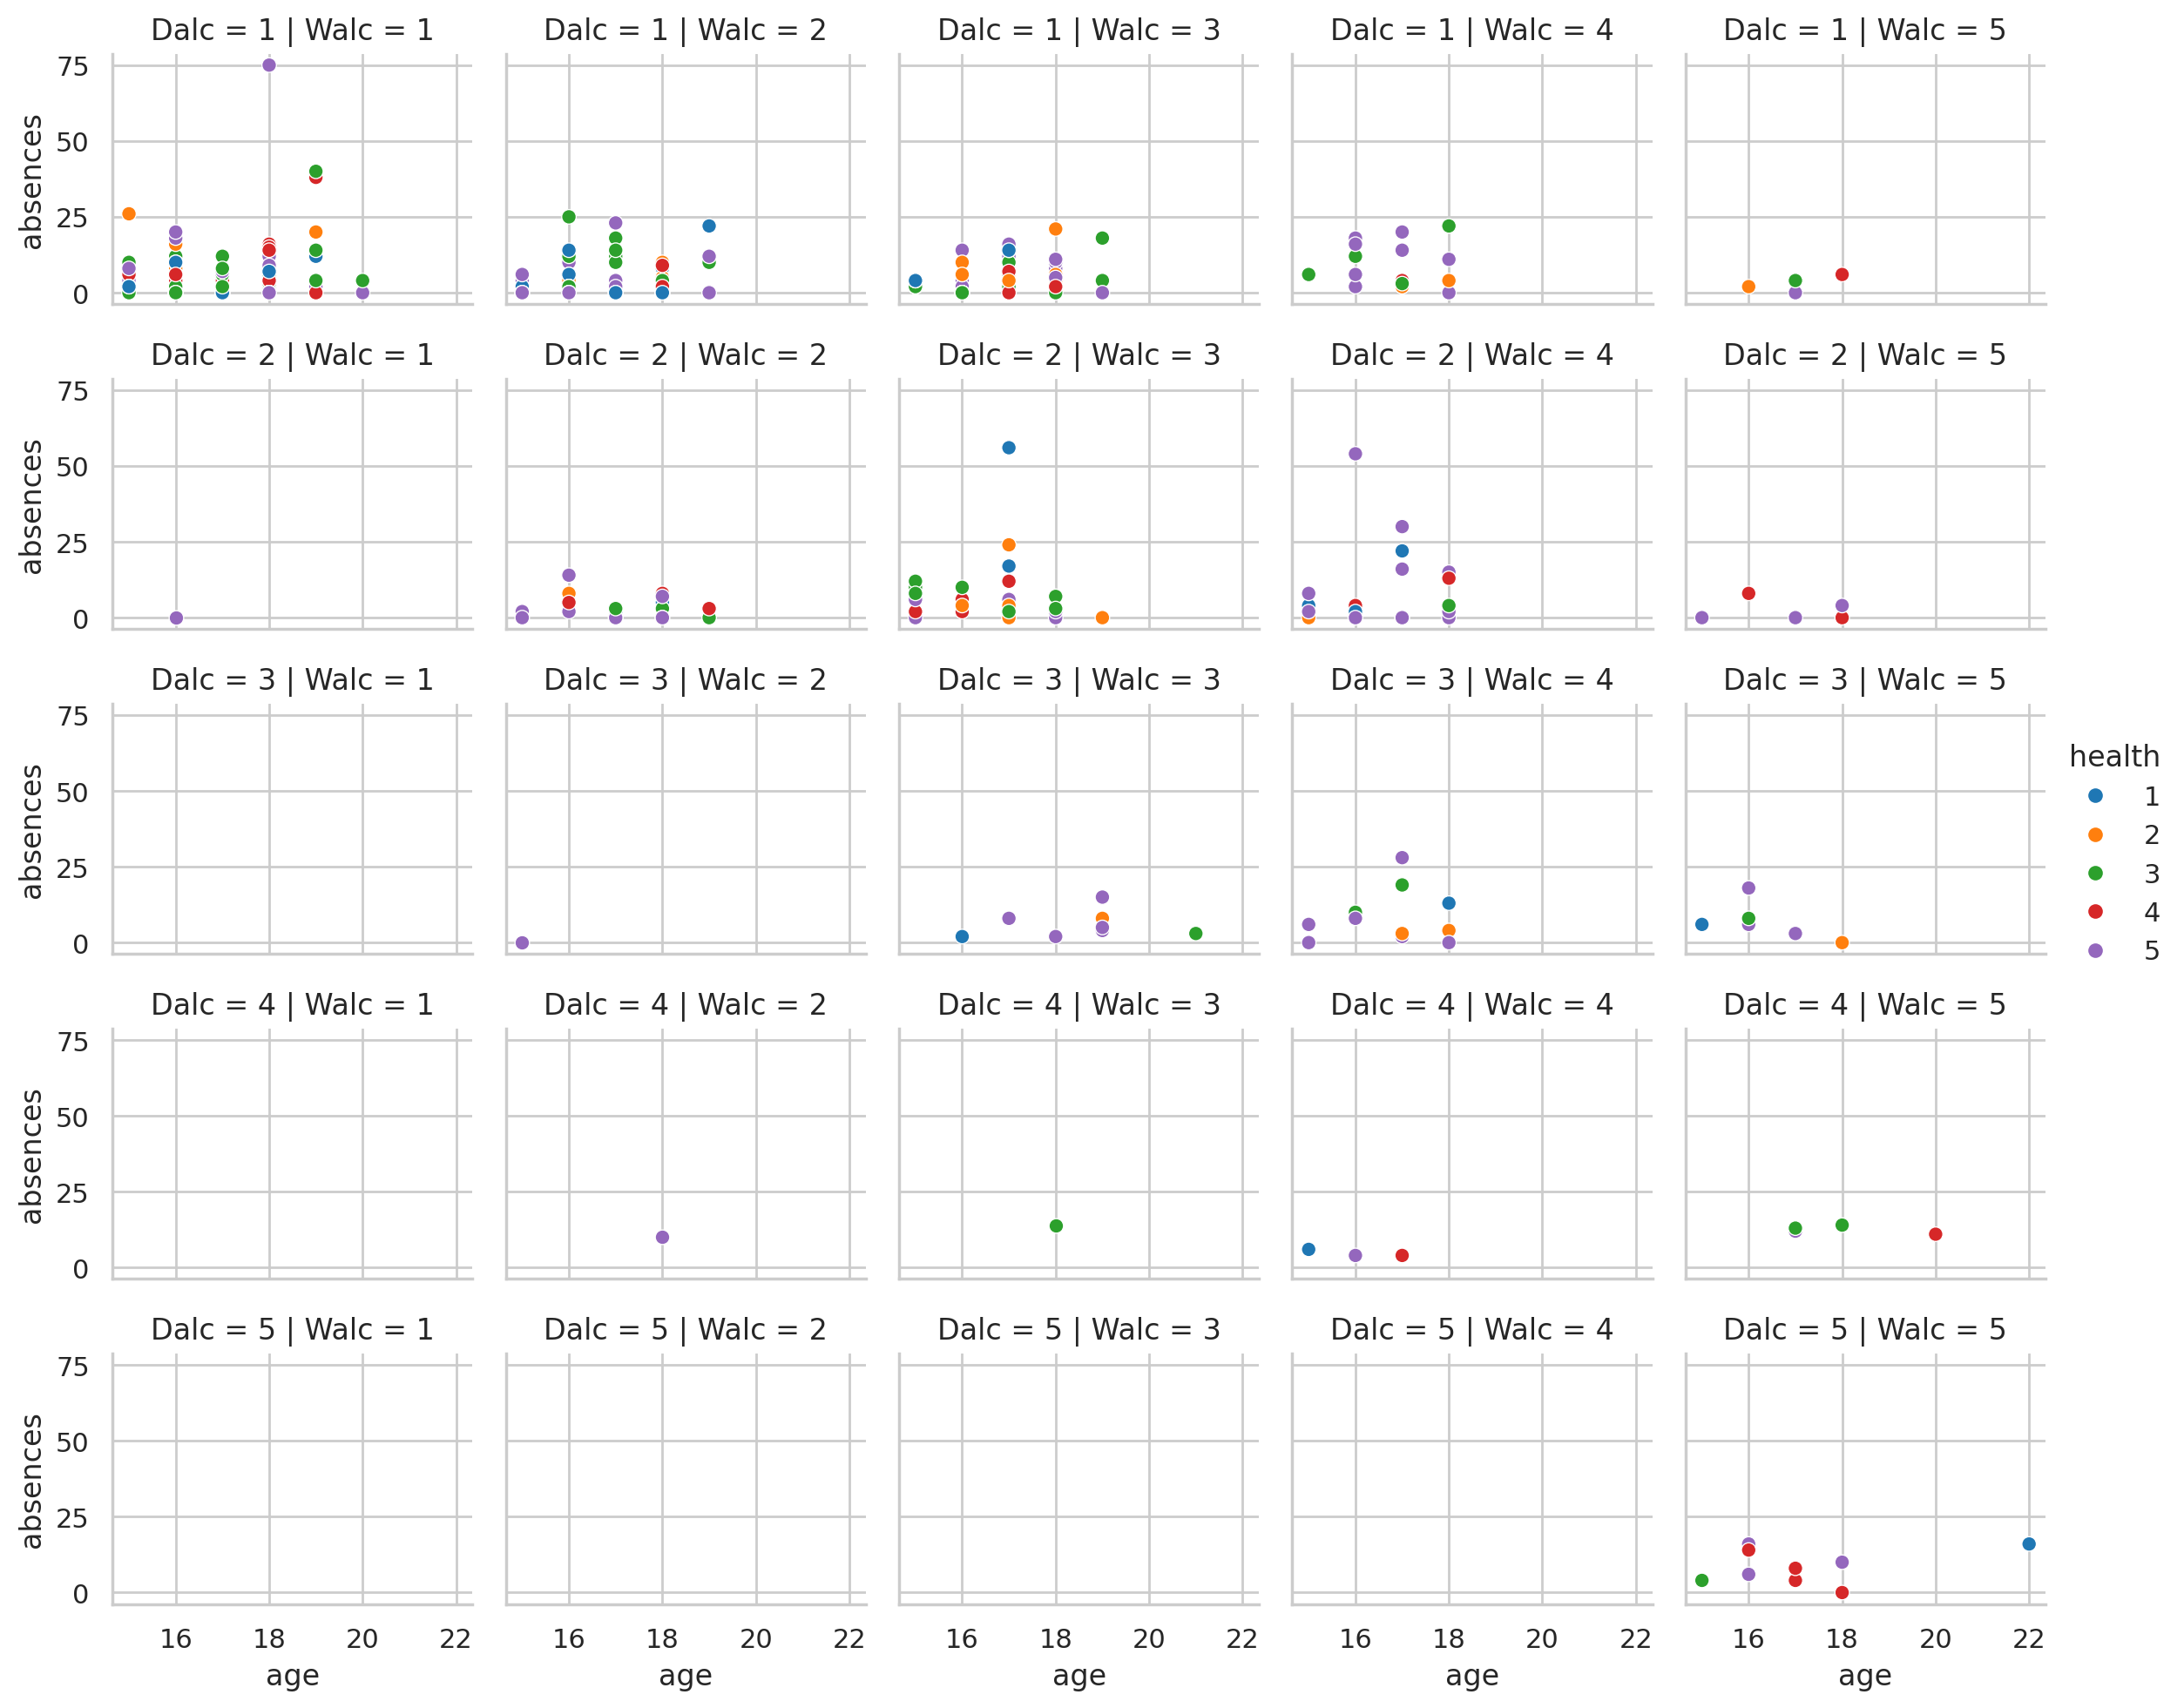

In [45]:
sns.relplot(data = alcohol, x = "age", y = "absences",
            hue = "health", col = "Walc", row = "Dalc",
            palette = "tab10", height = 2, aspect = 1.2);

Con este gráfico poco podemos concluir por la desagregación de los datos. Intentémoslo con otro tipo de descriptivos y gráficos que agreguen la información. Dado que la edad es un número entero y su rango es pequeño (valores entre 14 y 22) podemos convertirla a factor para visualizar mejor la relación con las ausencias.

In [46]:
# Convertimos age en categórica ordenada
# ordenamos los niveles y los convertimos en etiquetas
cats_to_order=sorted(alcohol.age.unique())
cats_dtype=pd.api.types.CategoricalDtype(cats_to_order,ordered=True)
alcohol['age_cat']=alcohol.age.astype(cats_dtype)
alcohol.age_cat.dtypes

CategoricalDtype(categories=[15, 16, 17, 18, 19, 20, 21, 22], ordered=True, categories_dtype=int64)

In [47]:
# Selección de variables involucradas
df = alcohol[['absences','age_cat','Dalc','Walc','health']]
# Obtenemos las medias de asusencias asociadas a las combinaciones de niveles de los factores
medias = df.groupby(['age_cat','Dalc','Walc','health']).mean().reset_index()
medias

/tmp/ipython-input-3918334619.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,age_cat,Dalc,Walc,health,absences
0,15,1,1,1,1.333333
1,15,1,1,2,9.000000
2,15,1,1,3,2.857143
3,15,1,1,4,5.600000
4,15,1,1,5,2.380952
...,...,...,...,...,...
995,22,5,5,1,16.000000
996,22,5,5,2,NaN
997,22,5,5,3,NaN
998,22,5,5,4,NaN


En la tabla aparecen algunas combinaciones que no se dan (valores NaN), pero no nos resulta posible identificarlas todas. Podemos plantear así una reagrupación de categorías en las variables consideradas para mejorar la visualización de la información y evite valores faltantes. Recodificamos:

* Variables Dalc, Walc y health agrupando los niveles 1 y 2, y el 4 y 5.
* Variable age agrupando los menores de edad y los mayores de edad.

In [48]:
# Recodificamos
df.Walc.replace({1: "1", 2: "1", 3: "2", 4: "3", 5: "3"}, inplace=True)
df.Dalc.replace({1: "1", 2: "1", 3: "2", 4: "3", 5: "3"}, inplace=True)
df.health.replace({1: "1", 2: "1", 3: "2", 4: "3", 5: "3"}, inplace=True)
df.age_cat.replace({15: "1", 16: "1", 17: "1", 18: "2", 19: "2", 20: "2", 21: "2", 22: "2"}, inplace=True)
# Evaluamos medias
medias = df.groupby(['age_cat','Dalc','Walc','health']).mean().reset_index()
medias

/tmp/ipython-input-2795372191.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/tmp/ipython-input-2795372191.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipython-input-2795372191.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will c

,age_cat,Dalc,Walc,health,absences
0,1,1,1,1,4.307692
1,1,1,1,2,4.390244
2,1,1,1,3,3.355556
3,1,1,2,1,10.437500
4,1,1,2,2,5.636364
5,1,1,2,3,4.461538
6,1,1,3,1,4.571429
7,1,1,3,2,6.250000
8,1,1,3,3,8.869565
9,1,2,1,1,NaN


Realizamos el gráfico de cajas

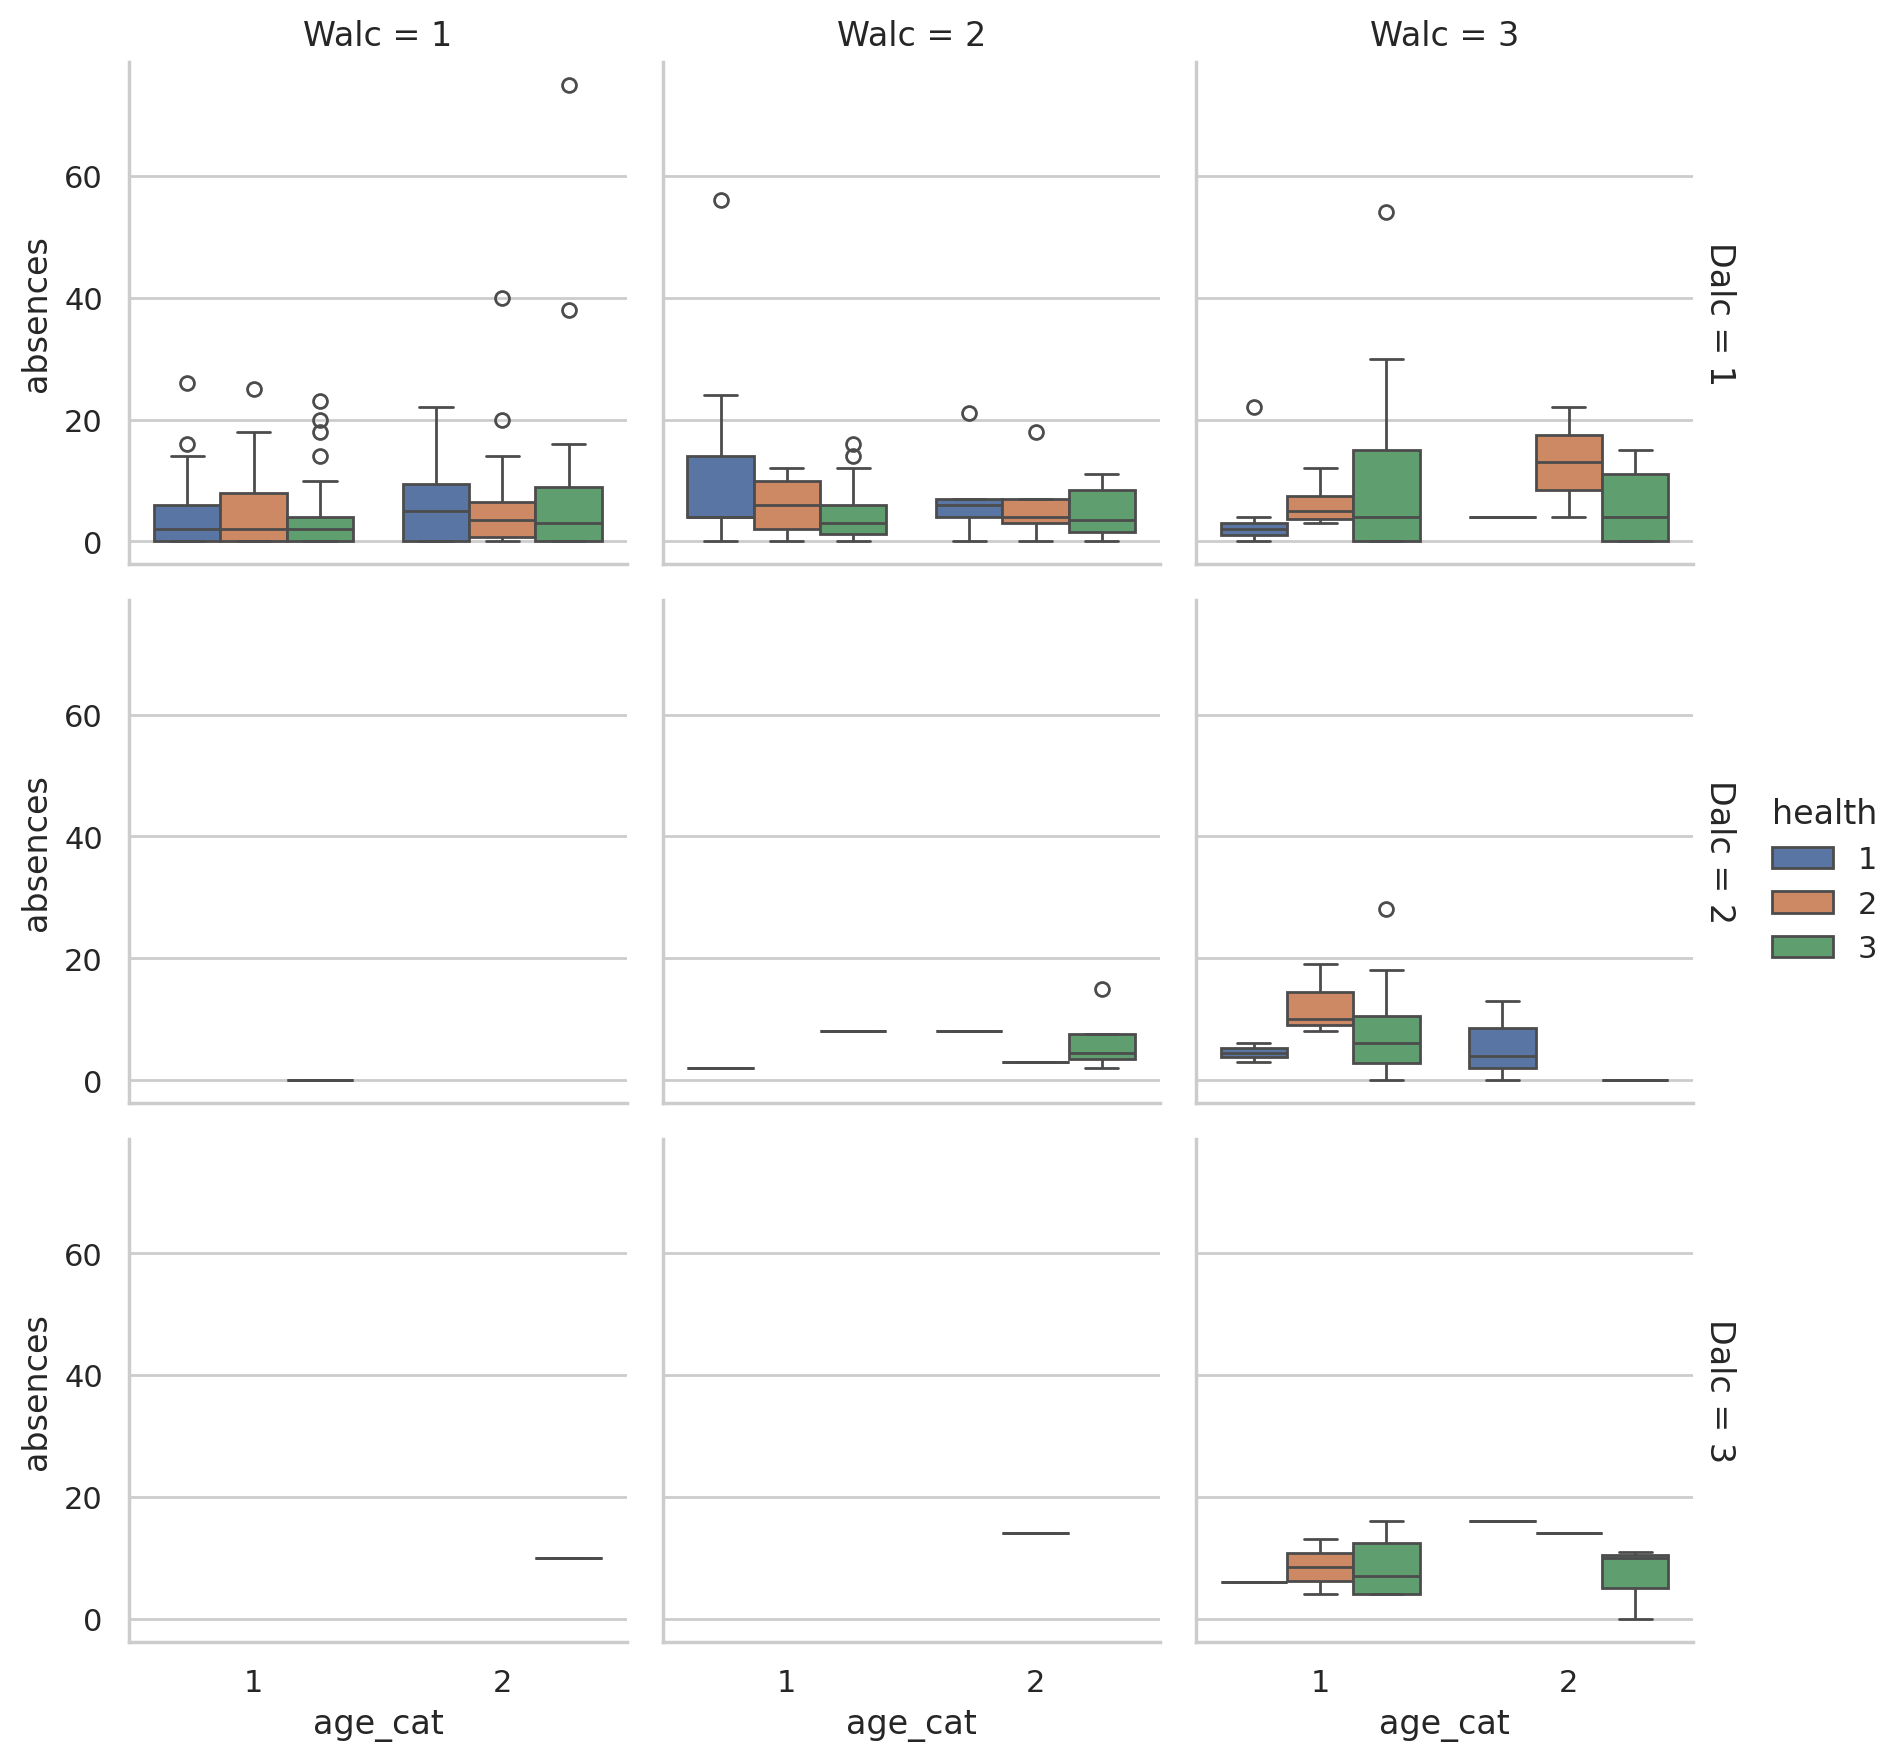

In [49]:
g = sns.catplot(x = "age_cat", y = "absences",
            col= "Walc", row = "Dalc", hue = "health",
            col_order = ["1", "2", "3"], row_order = ["1", "2", "3"], hue_order = ["1", "2", "3"],
            data = df, kind = "box", height = 3, margin_titles = True)
g.set_xticklabels(["1", "2"]);

Dado que los consumos diarios más bajos son los que concentran la mayor cantidad de datos, seleccionamos esas combinaciones para describir qué ocurre.

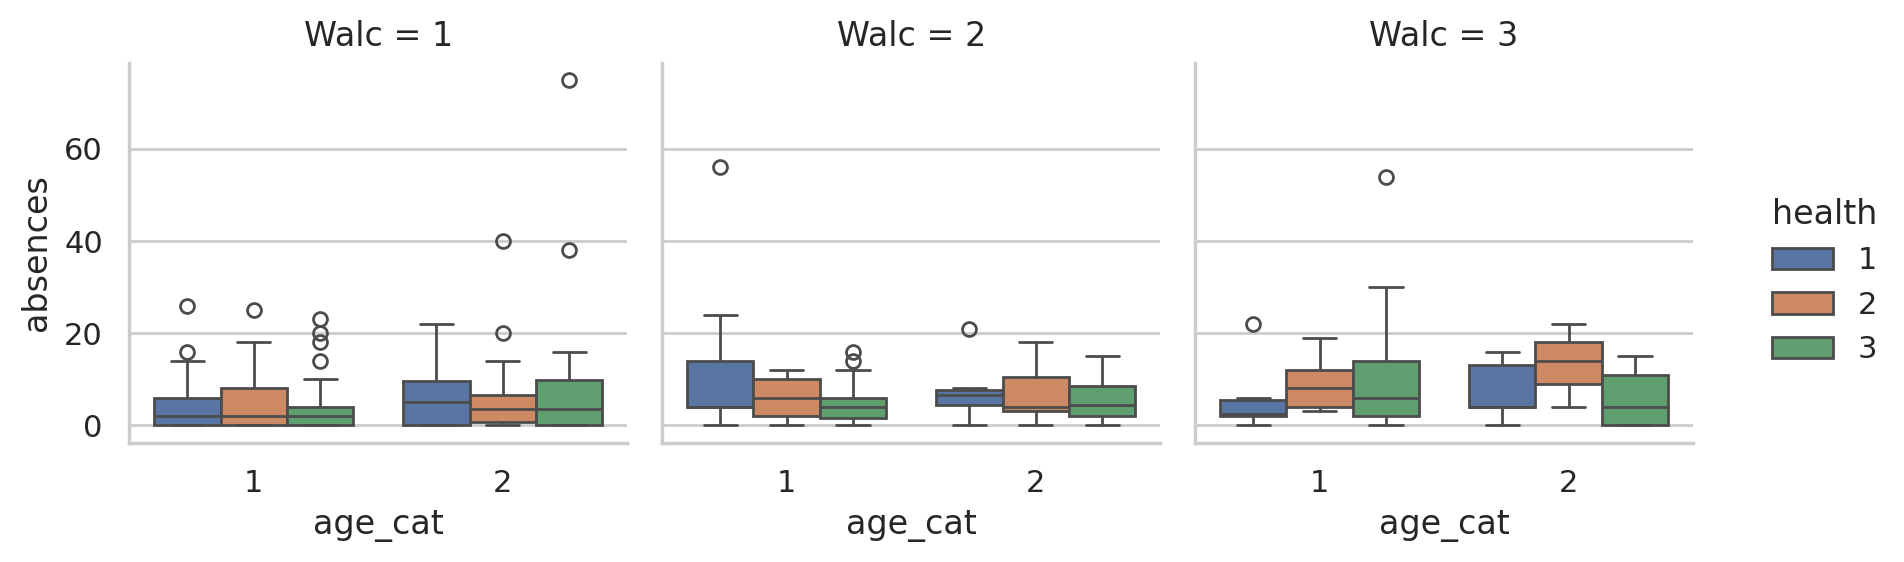

In [50]:
# Filtrado
df2 = df[df['Dalc'] == "1"]
# Gráfico
g = sns.catplot(x = "age_cat", y = "absences",
            col= "Walc", hue = "health",
            col_order = ["1", "2", "3"],  hue_order = ["1", "2", "3"],
            data = df, kind = "box", height = 3, margin_titles = True)
g.set_xticklabels(["1", "2"]);

Interpretemos los últimos gráficos obtenidos:

* En el grupo `Walc`=1 apenas se aprecian diferencias en el nivel de salud (`health`) y tampoco entre los distintos grupos de edad (`age_cat`).
* En el grupo `Walc`=2 y primer grupo de edad (`age_cat`=1) tampoco se aprecian diferencias sustanciales en el nivel de salud (`health`). En los sujetos mayores (`age_cat`=2) hay mayor variabilidad en las ausencias a clase para los sujetos con peor salud (`health`=1).

Procedemos ahora con otro ejemplo. Concretamnte nos centramos en le dataframe cereal. Investigamos ahora dos situaciones relativas a la variable `rating`, que identifica las posibilidades de cada cereal en términos de los informes que se derivan de la opinión de los consumidores.

¿Cómo se relaciona la valoración del consumidor, `rating`, con el nivel de grasa que contiene el cereal (`fat`)? Considera también diferencias por marca (`mfr`) y por tipo de cereal (`type`=cold/hot)


In [51]:
# Carga de datos 'cereal'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataPython/main/cereal.csv'
cereal = pd.read_csv(url)

# Etiquetamos los registros con el nombre de los cereales
cereal = cereal.set_index('name')
# Renombramos la variable type para que no coincida con función de python
cereal.rename(columns={'type': 'Type'}, inplace=True)
# Recodificamos las variables 'mfr' para identificar marcas y 'Type'
cereal.mfr.replace({"A": "American Home Food Products", "G": "General Mills", "K": "Kelloggs", "N": "Nabisco", "P": "Post", "Q": "Quaker Oats", "R": "Ralston Purina"}, inplace=True)
cereal.Type.replace({"C": "Cold", "H": "Hot"}, inplace=True)

/tmp/ipython-input-2242980102.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/tmp/ipython-input-2242980102.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df


Nos centramos en el análisis gráfico y solicitamos inicialmente un gráfico de dispersión entre 'rating' y 'fat', diferenciando por marca y por tipo, para intentar identificar el tipo de asociación entre ellas.

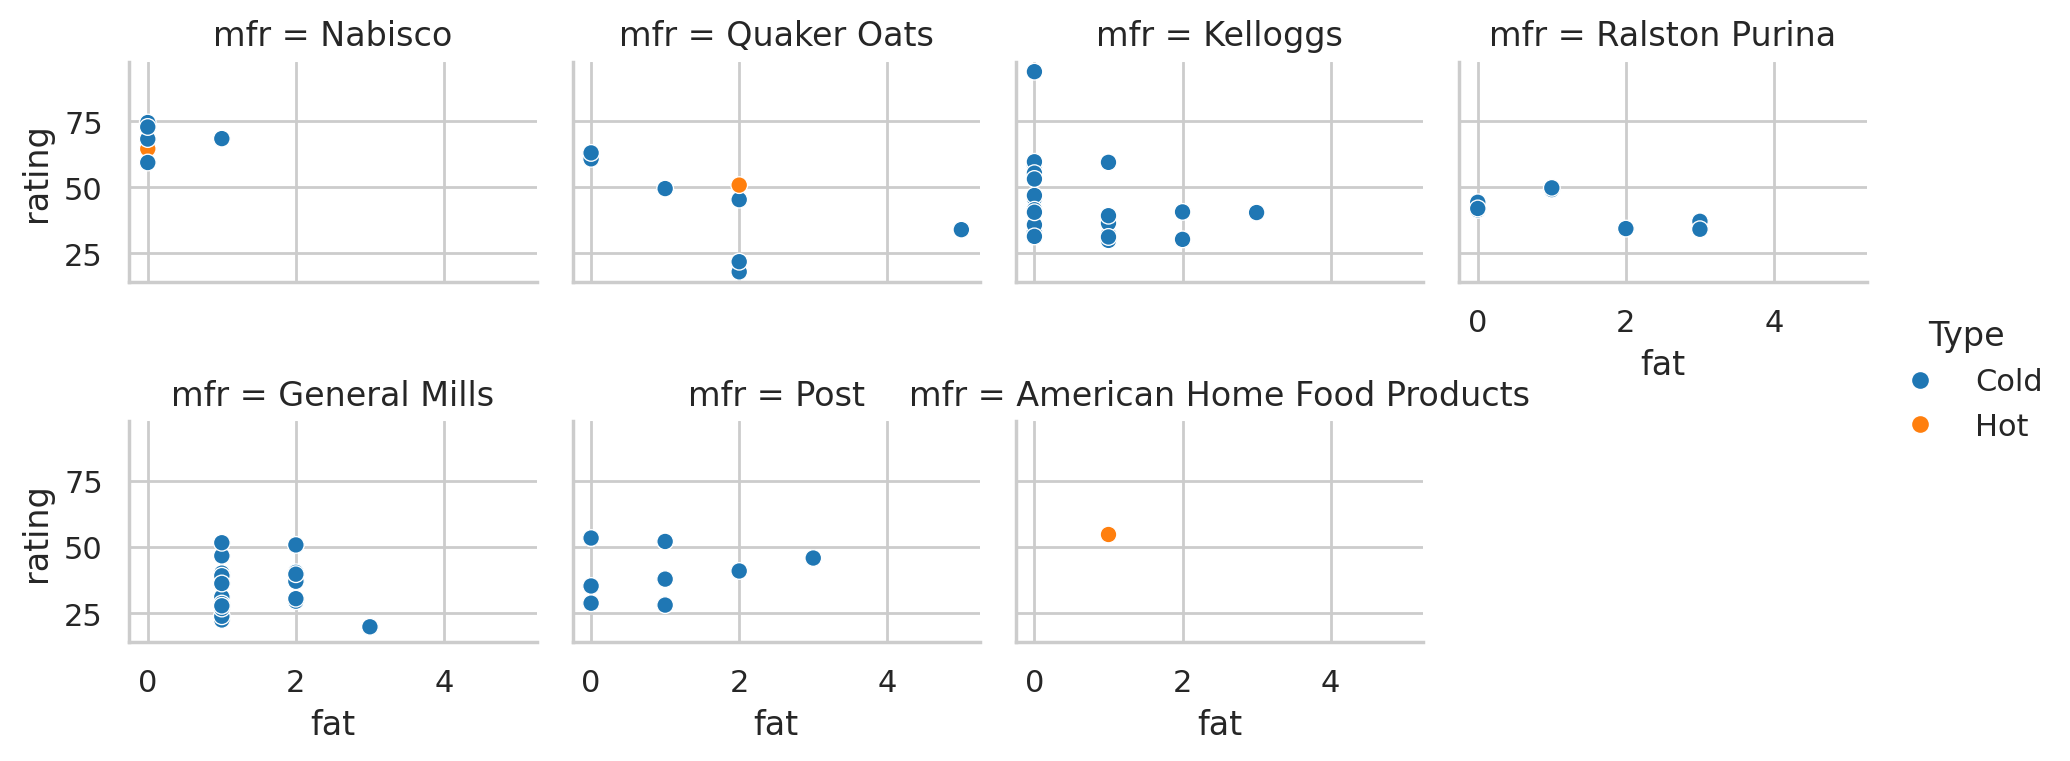

In [52]:
sns.relplot(data = cereal, x = "fat", y = "rating",
            hue = "Type", col = "mfr", col_wrap=4,
            palette = "tab10", height = 2, aspect = 1.2);

Dado que hay muy pocos cereales de tipo `hot`, filtramos sólo los de `Type`=Cold. Además, dado que `fat` toma sómo unos pocos valores enteros, podríamos tratarla como categórica para visualizar `rating` con gráficos de cajas (boxplot) en cada nivel de `fat`, diferenciando también las marcas con colores (`hue`).  

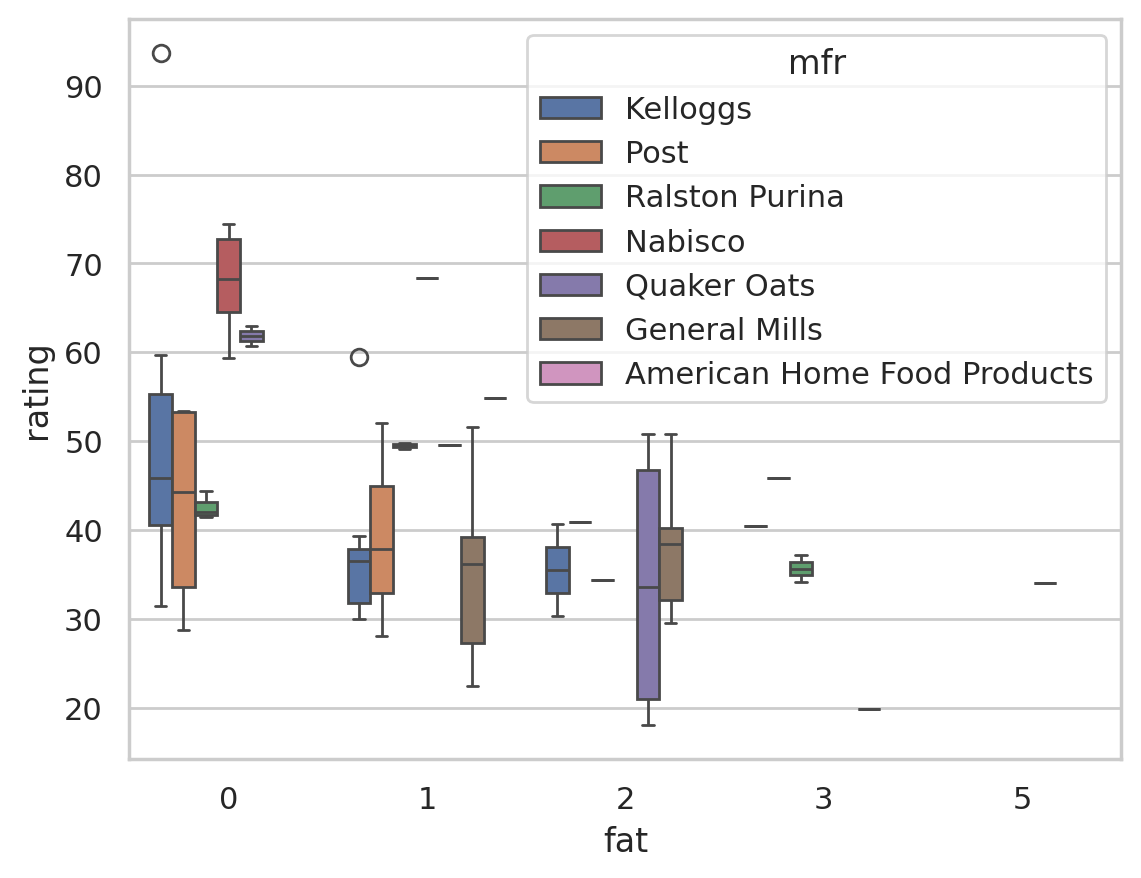

In [53]:
# Filtro
df = cereal[cereal['Type'] == "Cold"]
# Gráfico
sns.boxplot(data = cereal, x = "fat",y = "rating", hue = "mfr");

Entre las cosas que podemos destacar a partir del gráfico anterior:

1.   Hay un descenso generalizado de la valoración de los cereales cuando estos tienen mayor contenido en grasa (podemos visualizar una curva decreciente interpolando las medianas de las cajas).
2.   La marca Nabisco es la que tiene mejores puntuaciones y un menor contenido en grasa.
3.   La marca Quaker Oats presenta mayores contenidos en grasa que el resto y cierta disparidad de valoraciones, pero siempre por debajo de un `rating`=50.
4. Los cereales Kellogs, que presentan distintos productos con distinto nivel de grasa, tienen mejor valoración cuando el contenido en grasa es menor.

Concluyendo, podríamos afirmar que en general parece que las mejores valoraciones están asociadas a los cereales con menor contenido en grasa.


Finalizamos con nuevo ejmplo. en este caso nos centramos en el dataframe `FBI`. Estamos interesados en conocer cómo se relacionan las edades de la víctima y del perpetrador, diferenciando además por sexo y raza de la víctima.

En primer lugar seleccionaremos sólo los casos resueltos ya que son aquellos en los que tenemos información del perpetrador.

In [54]:
# Carga de datos 'fbi'
url = 'https://raw.githubusercontent.com/jmsocuellamos/DataSeg/master/FBI.csv'
fbi = pd.read_csv(url, sep =";") # en este caso el separador de campos es el ; en lugar de ,
# Filtramos los casos resueltos
fbi_resolved = fbi[fbi['Crime_Solved'] == "Yes"]

Dada la gran cantidad de datos que contiene este banco de datos, realizamos un descriptivo preliminar para detectar posibles observaciones anómalas en las variables numéricas consideradas.

In [55]:
fbi_resolved[['Victim_Age','Perpetrator_Age']].describe()

,Victim_Age,Perpetrator_Age
count,90179.000000,90179.000000
mean,35.495936,29.485501
std,41.931257,15.162832
min,0.000000,0.000000
25%,22.000000,20.000000
50%,30.000000,27.000000
75%,45.000000,38.000000
max,998.000000,99.000000


Podemos ver en el análisis descriptivo que aparecen ceros como valor mínimo, lo que resulta muy extraño especialmente para el atacante. En los máximos, también son raros un máximo de 99 años para el perpetrador, pero más aún el valor de 998 en las víctimas, que debe de tratarse de una errata.

Filtramos datos quitando los ceros en las variables `Age` y exigiendo un máximo de 100 años en la edad de las víctimas. Excluimos además los registros en los que se desconocen el sexo y/o la raza de la víctima.

Procedemos a continuación con el análisis descriptivo.

In [56]:
# Ejecutamos el conjunto de filtros propuestos:
fbi_resolved = fbi[(fbi['Crime_Solved'] == "Yes") &
                   (fbi['Victim_Age']<100) &
                   (fbi['Victim_Age']>0) &
                   (fbi['Perpetrator_Age']>0) &
                   (fbi['Victim_Sex']!="Unknown") &
                   (fbi['Victim_Race']!="Unknown")]

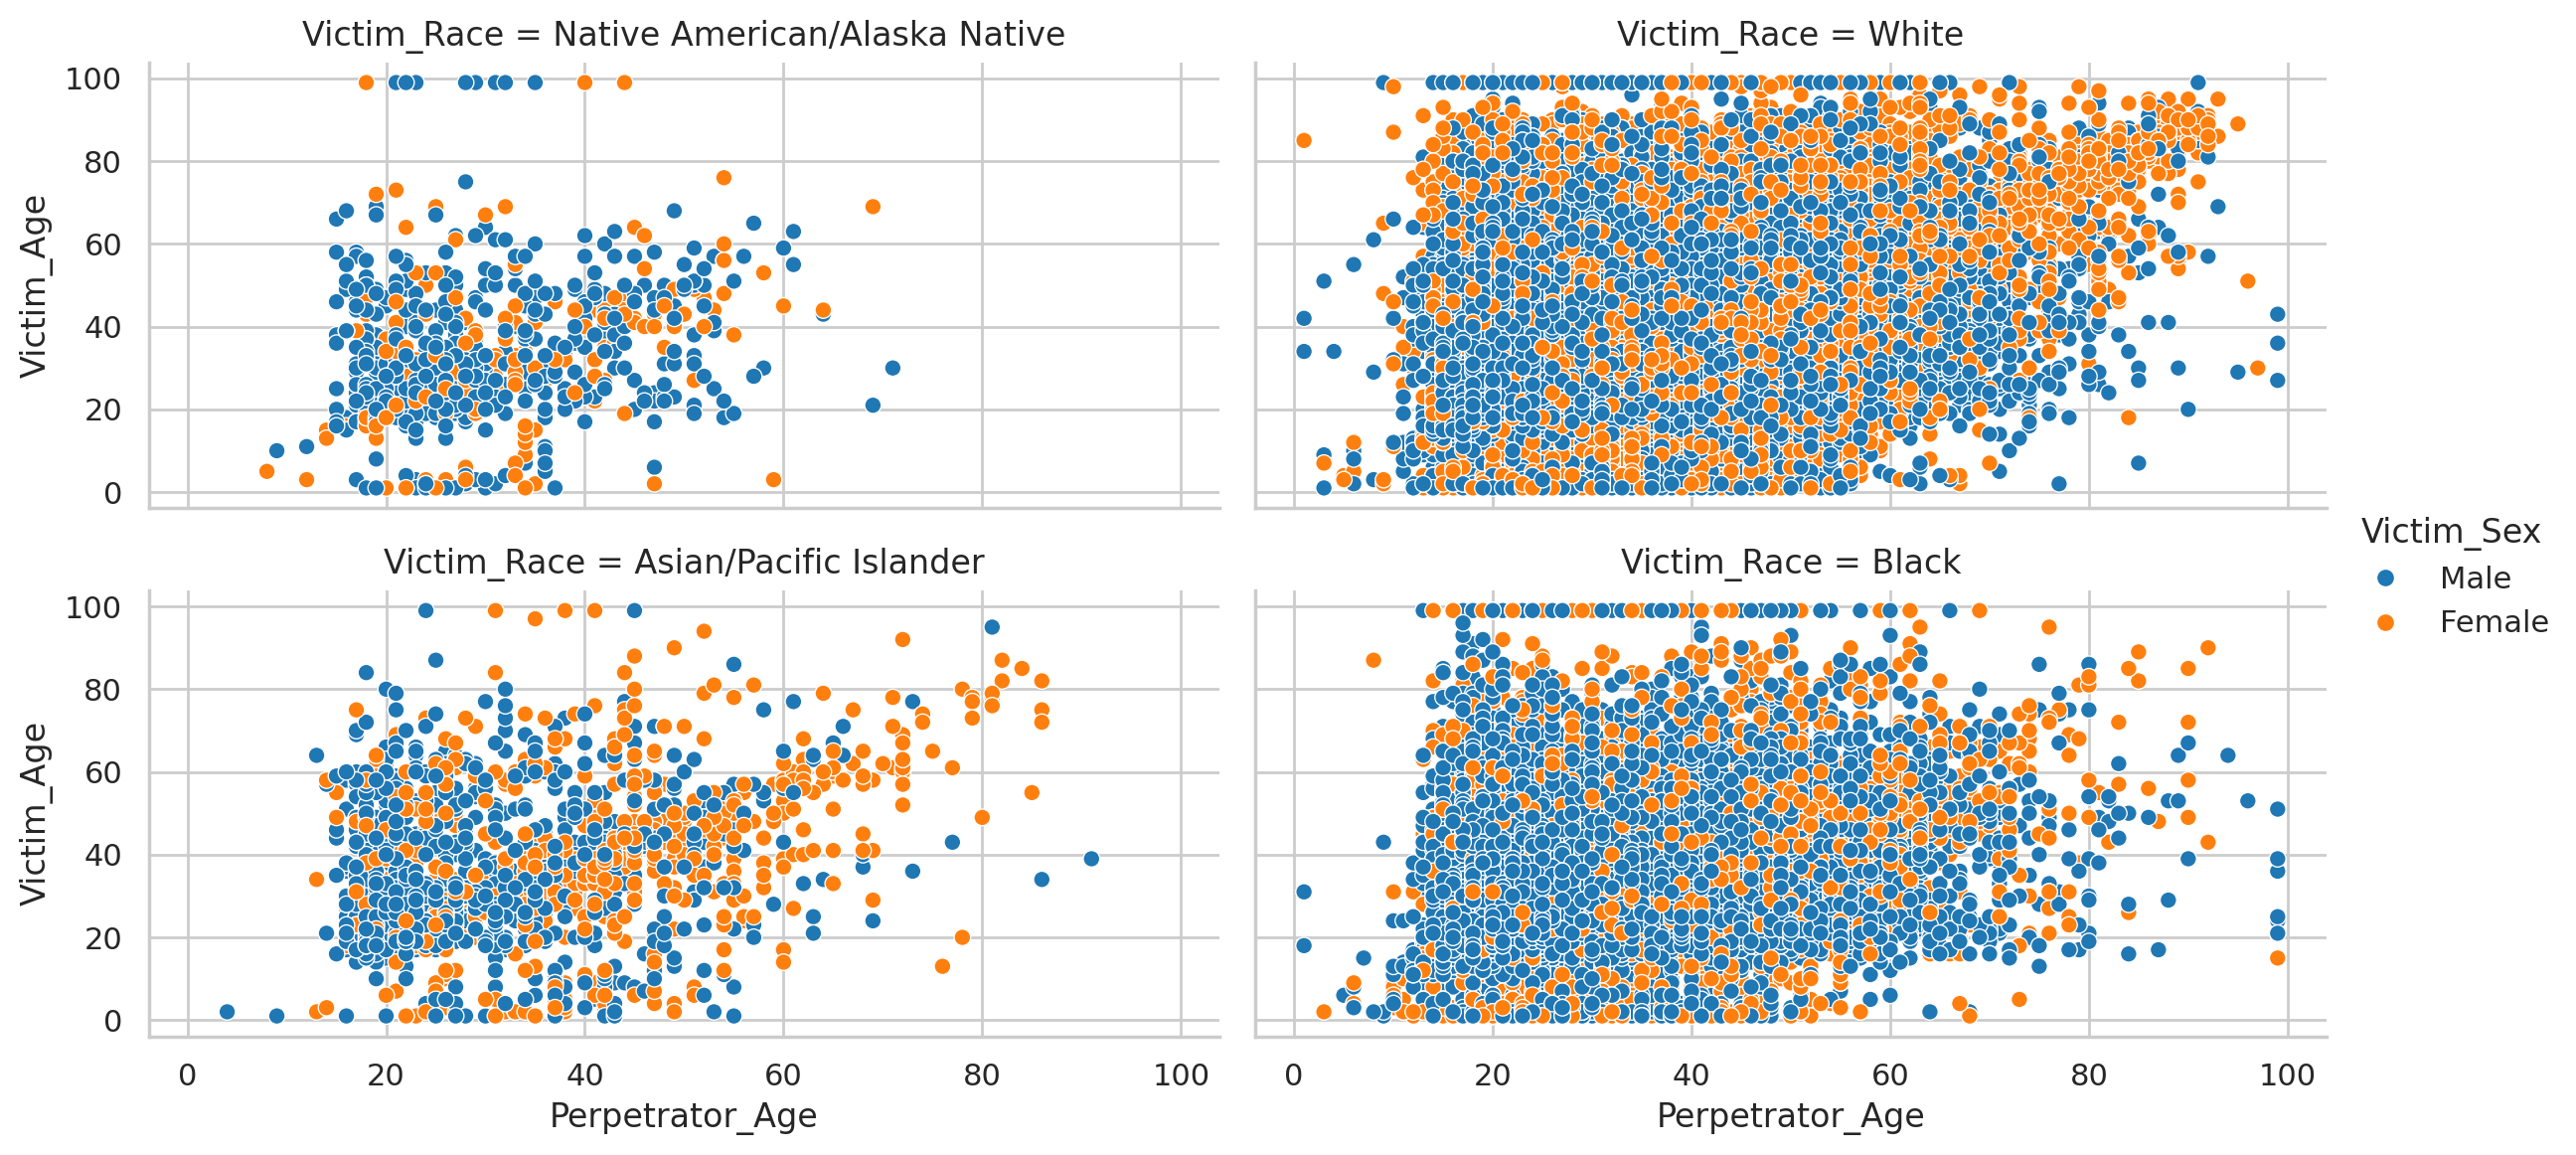

In [57]:
# Buscamos asociaciones entre las variables 'Age' en función de sexo y raza
sns.relplot(data = fbi_resolved, x = "Perpetrator_Age", y = "Victim_Age",
            hue = "Victim_Sex", col = "Victim_Race", col_wrap=2,
            palette = "tab10", height = 3, aspect = 2);

Con las nubes de puntos no vemos demasiado bien posibles relaciones, especialmente porque hay mucha información. Intentamos simplificar el análisis agrupando la edad de la víctima en diferentes grupos, con cortes 0, 18, 35, 50, 65, 80, +80. Seguiremos tratando como numérica la edad del perpetrador.

In [58]:
# Creamos la variable discretizada de edad de la víctima (si no está creada ya)
fbi_resolved['Victim_Age_cat'] = pd.cut(fbi_resolved.Victim_Age, bins=[0, 18, 35, 50, 65, 80, 100],
                                        include_lowest = True, right = False,ordered=True)

/tmp/ipython-input-2902110517.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


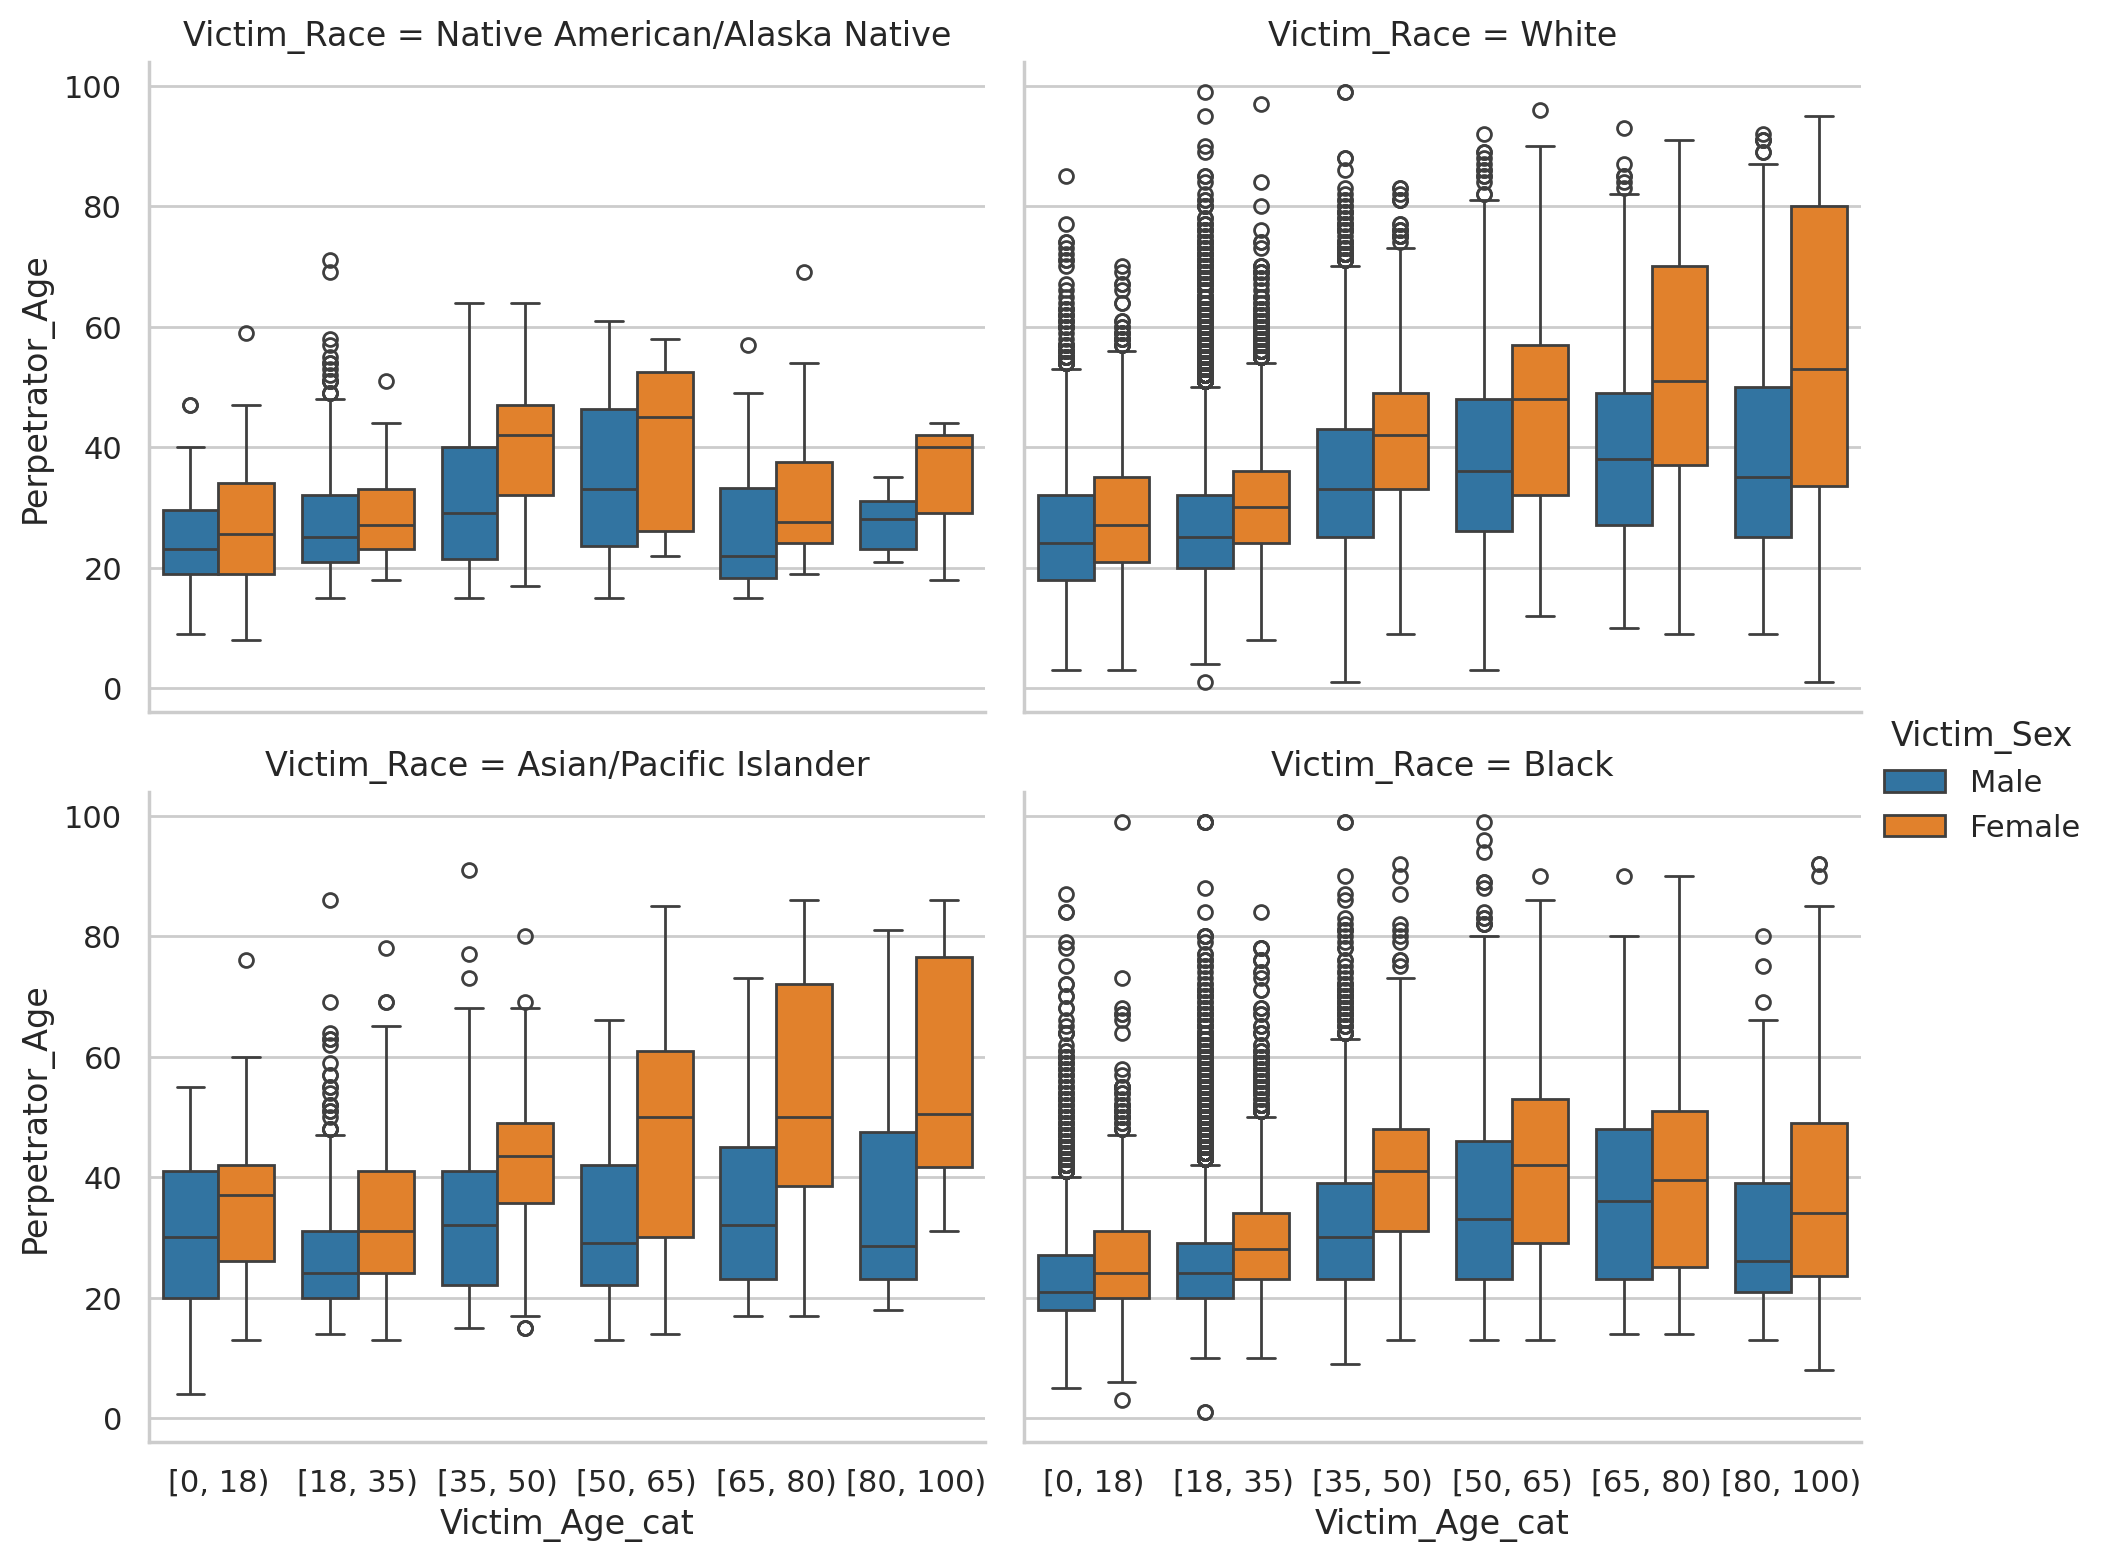

In [59]:
# Creamos ahora los gráficos de cajas
sns.catplot(data = fbi_resolved, y = "Perpetrator_Age", x = "Victim_Age_cat",
            hue = "Victim_Sex", col = "Victim_Race", kind ="box", col_wrap =2,
            palette = "tab10", height = 4, aspect = 1.2);

En todas las razas parece observarse una relación directa entre la edad del perpetrador y la edad de la víctima, dado que cuanto mayor es la edad del perpetrador, mayor es también la edad de la víctima. Esta relación parece más intensa en la mujeres que en los hombres; de hecho, en un mismo grupo de edad de la víctima, podemos ver que la edad mediana de la víctima es menor si es hombre que si es mujer.

